# Current Three-Backbone Comparison: RAGTruth Detection and Controller

This notebook compares the finalized **Qwen3-8B**, **LLaMA-3-8B-Instruct**, and
**Mistral-7B-Instruct-v0.2** experiments using the artifacts produced by the
current Controller-v5 SQuAD-v2 paper notebooks.

The comparison is built directly from the saved Google Drive outputs. It does
not retrain any backbone or recompute controller decisions.

## comparison content

### tables

1. Official RAGTruth detector comparison
2. Final Controller-v5 safety and utility comparison
3. Latency and controller-action comparison
4. Cross-model best-outcome comparison
5. Varied Controller-v5 demonstrations showing the response delivered to the end user

### figures

1. Published baselines versus the proposed fused probe on RAGTruth
2. RAGTruth versus HaluEval fused AUROC
3. Final Controller-v5 safety–quality profile, with marker size representing answerable coverage
4. Probe training curves for all three backbones
5. HaluEval ROC grid
6. Vanilla RAG versus Closed-Loop RAG
7. CEV, IAV, and fused-probe comparison

Every exported figure is saved at **300 dpi** with bold titles, labels, ticks,
legends, and annotations. Repeated legacy tables, hand-built demonstrations, and redundant figures are omitted.

## 1. Google Drive mount, imports, and publication-style formatting

In [83]:
from pathlib import Path
import json
import os
import sys
from typing import Any, Dict, Iterable, List, Mapping, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve
from IPython.display import display

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    DRIVE_ROOT = Path("/content/drive/MyDrive")
else:
    # This fallback is only for local verification.
    DRIVE_ROOT = Path(
        os.environ.get(
            "COMPARE_MODELS_DRIVE_ROOT",
            "/content/drive/MyDrive",
        )
    )

COMPARE_OUTPUT_DIR = (
    DRIVE_ROOT
    / "compare_models_controller_v5_current"
)
TABLE_DIR = COMPARE_OUTPUT_DIR / "tables"
FIGURE_DIR = COMPARE_OUTPUT_DIR / "figures"

for directory in (
    COMPARE_OUTPUT_DIR,
    TABLE_DIR,
    FIGURE_DIR,
):
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

FIGURE_DPI = 300

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": FIGURE_DPI,
    "font.size": 12,
    "font.weight": "bold",
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10,
    "lines.linewidth": 2.2,
    "lines.markersize": 7,
})

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 110)
pd.set_option("display.width", 220)

MODEL_ORDER = [
    "Qwen3-8B",
    "LLaMA-3-8B-Instruct",
    "Mistral-7B-Instruct-v0.2",
]

MODEL_BASE_DIRS = {
    "Qwen3-8B": (
        DRIVE_ROOT
        / "qwen_colab_a100_ragtruth18k_test_run"
    ),
    "LLaMA-3-8B-Instruct": (
        DRIVE_ROOT
        / "llama_colab_a100_ragtruth18k_test_run"
    ),
    "Mistral-7B-Instruct-v0.2": (
        DRIVE_ROOT
        / "mistral_colab_a100_ragtruth18k_test_run"
    ),
}

print({
    "drive_root": str(DRIVE_ROOT),
    "comparison_output": str(COMPARE_OUTPUT_DIR),
    "figure_dpi": FIGURE_DPI,
})

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
{'drive_root': '/content/drive/MyDrive', 'comparison_output': '/content/drive/MyDrive/compare_models_controller_v5_current', 'figure_dpi': 300}


## 2. Resolve and validate the current notebook artifacts

In [84]:
def require_file(
    path: Path,
    description: str,
) -> Path:
    if not path.is_file():
        raise FileNotFoundError(
            f"Missing {description}:\n{path}\n\n"
            "Run the corresponding backbone notebook through its "
            "final verification cell before running this comparison."
        )
    return path


def load_json(path: Path) -> Dict[str, Any]:
    with path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        return json.load(handle)


def save_json(
    path: Path,
    payload: Mapping[str, Any],
) -> None:
    with path.open(
        "w",
        encoding="utf-8",
    ) as handle:
        json.dump(
            payload,
            handle,
            indent=2,
            ensure_ascii=False,
        )


def save_figure(
    fig: plt.Figure,
    filename: str,
) -> Path:
    output_path = FIGURE_DIR / filename
    fig.savefig(
        output_path,
        dpi=FIGURE_DPI,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.show()
    plt.close(fig)
    print(f"Saved: {output_path}")
    return output_path


def artifact_paths(
    base_dir: Path,
) -> Dict[str, Path]:
    controller_dir = (
        base_dir
        / "controller_v5_squadv2_paper_ablation_outputs"
    )

    return {
        "base_dir": base_dir,
        "detector_metrics": (
            base_dir
            / "outputs"
            / "ragtruth_official_test_metrics.json"
        ),
        "training_history": (
            base_dir
            / "outputs"
            / "probe_oof_training_history.csv"
        ),
        "controller_summary": (
            controller_dir
            / "squad_v2_evaluation"
            / "controller_v5_squadv2_final_summary.json"
        ),
        "controller_evaluation": (
            controller_dir
            / "squad_v2_evaluation"
            / "controller_v5_squadv2_final_evaluation.csv"
        ),
        "signal_ablation": (
            controller_dir
            / "signal_ablation"
            / "signal_ablation_final.csv"
        ),
        "demonstrations": (
            controller_dir
            / "controller_demonstrations"
            / "squad_v2_varied_controller_demonstrations_summary.csv"
        ),
        "halueval_metrics": (
            controller_dir
            / "optional_halueval"
            / "halueval_optional_auroc.json"
        ),
        "halueval_predictions": (
            controller_dir
            / "optional_halueval"
            / "halueval_optional_predictions.csv"
        ),
        "run_manifest": (
            controller_dir
            / "run_manifest_squadv2_paper_ablation.json"
        ),
    }


ARTIFACTS = {
    model_name: artifact_paths(
        MODEL_BASE_DIRS[model_name]
    )
    for model_name
    in MODEL_ORDER
}

REQUIRED_ARTIFACT_KEYS = [
    "detector_metrics",
    "training_history",
    "controller_summary",
    "controller_evaluation",
    "signal_ablation",
    "demonstrations",
    "halueval_metrics",
    "halueval_predictions",
    "run_manifest",
]

artifact_validation_rows = []

for model_name in MODEL_ORDER:
    model_paths = ARTIFACTS[
        model_name
    ]

    if not model_paths[
        "base_dir"
    ].is_dir():
        raise FileNotFoundError(
            f"Missing model output folder:\n"
            f"{model_paths['base_dir']}"
        )

    for artifact_key in REQUIRED_ARTIFACT_KEYS:
        artifact_path = require_file(
            model_paths[
                artifact_key
            ],
            (
                f"{model_name} "
                f"{artifact_key}"
            ),
        )
        artifact_validation_rows.append({
            "Model": model_name,
            "Artifact": artifact_key,
            "Path": str(artifact_path),
            "Size (KB)": round(
                artifact_path.stat().st_size
                / 1024.0,
                2,
            ),
        })

artifact_validation_df = pd.DataFrame(
    artifact_validation_rows
)

display(
    artifact_validation_df
)

artifact_validation_df.to_csv(
    TABLE_DIR / "artifact_validation.csv",
    index=False,
)

,Model,Artifact,Path,Size (KB)
0,Qwen3-8B,detector_metrics,/content/drive/MyDrive/qwen_colab_a100_ragtruth18k_test_run/outputs/ragtruth_official_test_metrics.json,0.60
1,Qwen3-8B,training_history,/content/drive/MyDrive/qwen_colab_a100_ragtruth18k_test_run/outputs/probe_oof_training_history.csv,1.46
2,Qwen3-8B,controller_summary,/content/drive/MyDrive/qwen_colab_a100_ragtruth18k_test_run/controller_v5_squadv2_paper_ablation_outputs/s...,2.04
3,Qwen3-8B,controller_evaluation,/content/drive/MyDrive/qwen_colab_a100_ragtruth18k_test_run/controller_v5_squadv2_paper_ablation_outputs/s...,342.51
4,Qwen3-8B,signal_ablation,/content/drive/MyDrive/qwen_colab_a100_ragtruth18k_test_run/controller_v5_squadv2_paper_ablation_outputs/s...,0.61
5,Qwen3-8B,demonstrations,/content/drive/MyDrive/qwen_colab_a100_ragtruth18k_test_run/controller_v5_squadv2_paper_ablation_outputs/c...,0.86
6,Qwen3-8B,halueval_metrics,/content/drive/MyDrive/qwen_colab_a100_ragtruth18k_test_run/controller_v5_squadv2_paper_ablation_outputs/o...,0.45
7,Qwen3-8B,halueval_predictions,/content/drive/MyDrive/qwen_colab_a100_ragtruth18k_test_run/controller_v5_squadv2_paper_ablation_outputs/o...,11344.18
8,Qwen3-8B,run_manifest,/content/drive/MyDrive/qwen_colab_a100_ragtruth18k_test_run/controller_v5_squadv2_paper_ablation_outputs/r...,18.39
9,LLaMA-3-8B-Instruct,detector_metrics,/content/drive/MyDrive/llama_colab_a100_ragtruth18k_test_run/outputs/ragtruth_official_test_metrics.json,0.60


## 3. Load the verified results and construct non-duplicated comparison data

In [85]:
EXPECTED_CURRENT_RESULTS = {
    "Qwen3-8B": {
        "ragtruth_fused_auroc": 0.8887968803471162,
        "halueval_fused_auroc": 0.68300746,
        "controller_answerability_accuracy": 0.858,
        "controller_false_answer_rate": 0.174,
    },
    "LLaMA-3-8B-Instruct": {
        "ragtruth_fused_auroc": 0.8819193759728545,
        "halueval_fused_auroc": 0.80939538,
        "controller_answerability_accuracy": 0.861,
        "controller_false_answer_rate": 0.156,
    },
    "Mistral-7B-Instruct-v0.2": {
        "ragtruth_fused_auroc": 0.8719842641251385,
        "halueval_fused_auroc": 0.7205353999999999,
        "controller_answerability_accuracy": 0.859,
        "controller_false_answer_rate": 0.14,
    },
}

loaded = {}
detector_rows = []
controller_rows = []
latency_action_rows = []
halueval_rows = []
demonstration_frames = []
training_histories = {}

for model_name in MODEL_ORDER:
    model_paths = ARTIFACTS[
        model_name
    ]

    detector = load_json(
        model_paths[
            "detector_metrics"
        ]
    )
    controller = load_json(
        model_paths[
            "controller_summary"
        ]
    )
    halueval = load_json(
        model_paths[
            "halueval_metrics"
        ]
    )
    manifest = load_json(
        model_paths[
            "run_manifest"
        ]
    )

    controller_eval = pd.read_csv(
        model_paths[
            "controller_evaluation"
        ]
    )
    signal_ablation = pd.read_csv(
        model_paths[
            "signal_ablation"
        ]
    )
    demonstrations = pd.read_csv(
        model_paths[
            "demonstrations"
        ]
    )
    halueval_predictions = pd.read_csv(
        model_paths[
            "halueval_predictions"
        ]
    )
    training_history = pd.read_csv(
        model_paths[
            "training_history"
        ]
    )

    loaded[model_name] = {
        "detector": detector,
        "controller": controller,
        "halueval": halueval,
        "manifest": manifest,
        "controller_evaluation": controller_eval,
        "signal_ablation": signal_ablation,
        "demonstrations": demonstrations,
        "halueval_predictions": halueval_predictions,
        "training_history": training_history,
    }

    detector_rows.append({
        "Backbone": model_name,
        "CEV AUROC": detector[
            "cev_auroc"
        ],
        "IAV AUROC": detector[
            "iav_auroc"
        ],
        "Fused AUROC": detector[
            "fused_auroc"
        ],
        "Fused AUROC 95% CI": (
            f"{detector['fused_auroc_ci_95_lower']:.4f}"
            f"–"
            f"{detector['fused_auroc_ci_95_upper']:.4f}"
        ),
        "AUPRC": detector[
            "fused_auprc"
        ],
        "Balanced accuracy": detector[
            "balanced_accuracy"
        ],
        "Hallucination F1": detector[
            "f1"
        ],
        "Brier score": detector[
            "brier_score"
        ],
        "ECE": detector[
            "ece_10_bins"
        ],
    })

    controller_rows.append({
        "Backbone": model_name,
        "Vanilla answerability accuracy": controller[
            "vanilla_answerability_accuracy"
        ],
        "Controller answerability accuracy": controller[
            "controller_answerability_accuracy"
        ],
        "Accuracy gain": (
            controller[
                "controller_answerability_accuracy"
            ]
            - controller[
                "vanilla_answerability_accuracy"
            ]
        ),
        "Vanilla false-answer rate": controller[
            "vanilla_false_answer_rate"
        ],
        "Controller false-answer rate": controller[
            "controller_false_answer_rate"
        ],
        "False-answer reduction": (
            controller[
                "vanilla_false_answer_rate"
            ]
            - controller[
                "controller_false_answer_rate"
            ]
        ),
        "Answerable coverage": controller[
            "controller_answerable_coverage"
        ],
        "Answerable F1 — overall": controller[
            "controller_answerable_token_f1_overall"
        ],
        "Answerable F1 — delivered": controller[
            "controller_answerable_token_f1_among_delivered"
        ],
    })

    actions = controller[
        "action_counts_across_attempts"
    ]
    vanilla_mean = controller[
        "vanilla_mean_latency_sec"
    ]
    controller_mean = controller[
        "controller_mean_latency_sec"
    ]
    vanilla_p95 = controller[
        "vanilla_p95_latency_sec"
    ]
    controller_p95 = controller[
        "controller_p95_latency_sec"
    ]

    latency_action_rows.append({
        "Backbone": model_name,
        "Vanilla mean latency (s)": vanilla_mean,
        "Controller mean latency (s)": controller_mean,
        "Mean overhead (%)": (
            100.0
            * (
                controller_mean
                - vanilla_mean
            )
            / vanilla_mean
        ),
        "Vanilla P95 latency (s)": vanilla_p95,
        "Controller P95 latency (s)": controller_p95,
        "P95 overhead (%)": (
            100.0
            * (
                controller_p95
                - vanilla_p95
            )
            / vanilla_p95
        ),
        "Accept actions": int(
            actions.get(
                "accept",
                0,
            )
        ),
        "Abstain actions": int(
            actions.get(
                "abstain",
                0,
            )
        ),
        "Regenerate actions": int(
            actions.get(
                "regenerate",
                0,
            )
        ),
    })

    halueval_rows.append({
        "Backbone": model_name,
        "CEV AUROC": halueval[
            "cev_auroc_raw"
        ],
        "IAV AUROC": halueval[
            "iav_auroc_raw"
        ],
        "Fused AUROC": halueval[
            "fused_auroc_raw"
        ],
        "Fused AUROC 95% CI": (
            f"{halueval.get('fused_auroc_raw_ci_95_lower', halueval.get('fused_auroc_ci_95_lower')):.4f}"
            f"–"
            f"{halueval.get('fused_auroc_raw_ci_95_upper', halueval.get('fused_auroc_ci_95_upper')):.4f}"
        ),
        "Polarity inversion observed": bool(
            halueval.get(
                "cev_polarity_inverted",
                False,
            )
            or halueval.get(
                "iav_polarity_inverted",
                False,
            )
            or halueval.get(
                "fused_polarity_inverted",
                False,
            )
        ),
    })

    observed_mask = (
        demonstrations[
            "Observed"
        ]
        .astype(str)
        .str.lower()
        .isin([
            "true",
            "1",
            "yes",
        ])
    )
    demonstrations = demonstrations.loc[
        observed_mask
    ].copy()
    demonstrations.insert(
        0,
        "Backbone",
        model_name,
    )
    demonstration_frames.append(
        demonstrations
    )

    training_histories[
        model_name
    ] = training_history.copy()

detector_df = (
    pd.DataFrame(
        detector_rows
    )
    .set_index(
        "Backbone"
    )
    .loc[
        MODEL_ORDER
    ]
    .reset_index()
)

controller_df = (
    pd.DataFrame(
        controller_rows
    )
    .set_index(
        "Backbone"
    )
    .loc[
        MODEL_ORDER
    ]
    .reset_index()
)

latency_action_df = (
    pd.DataFrame(
        latency_action_rows
    )
    .set_index(
        "Backbone"
    )
    .loc[
        MODEL_ORDER
    ]
    .reset_index()
)

halueval_df = (
    pd.DataFrame(
        halueval_rows
    )
    .set_index(
        "Backbone"
    )
    .loc[
        MODEL_ORDER
    ]
    .reset_index()
)

demonstrations_df = pd.concat(
    demonstration_frames,
    ignore_index=True,
)

print(
    "Loaded current verified artifacts for:",
    ", ".join(
        MODEL_ORDER
    ),
)

Loaded current verified artifacts for: Qwen3-8B, LLaMA-3-8B-Instruct, Mistral-7B-Instruct-v0.2


## 4. Official RAGTruth detector comparison

In [86]:
ragtruth_table = detector_df[[
    "Backbone",
    "CEV AUROC",
    "IAV AUROC",
    "Fused AUROC",
    "Fused AUROC 95% CI",
    "AUPRC",
    "Balanced accuracy",
    "Hallucination F1",
    "Brier score",
    "ECE",
]].copy()

display(
    ragtruth_table.style.format({
        "CEV AUROC": "{:.4f}",
        "IAV AUROC": "{:.4f}",
        "Fused AUROC": "{:.4f}",
        "AUPRC": "{:.4f}",
        "Balanced accuracy": "{:.4f}",
        "Hallucination F1": "{:.4f}",
        "Brier score": "{:.4f}",
        "ECE": "{:.4f}",
    })
)

ragtruth_table.to_csv(
    TABLE_DIR
    / "official_ragtruth_detector_comparison.csv",
    index=False,
)

,Backbone,CEV AUROC,IAV AUROC,Fused AUROC,Fused AUROC 95% CI,AUPRC,Balanced accuracy,Hallucination F1,Brier score,ECE
0,Qwen3-8B,0.8878,0.8813,0.8888,0.8756–0.9013,0.8130,0.8010,0.7365,0.1293,0.0574
1,LLaMA-3-8B-Instruct,0.8787,0.8804,0.8819,0.8687–0.8946,0.8123,0.7921,0.7259,0.1328,0.0643
2,Mistral-7B-Instruct-v0.2,0.8687,0.8669,0.8720,0.8578–0.8851,0.8042,0.7850,0.7172,0.1382,0.0617


## 5. Final Controller-v5 safety and utility comparison

In [87]:
controller_table = controller_df.copy()

display(
    controller_table.style.format({
        "Vanilla answerability accuracy": "{:.1%}",
        "Controller answerability accuracy": "{:.1%}",
        "Accuracy gain": "{:+.1%}",
        "Vanilla false-answer rate": "{:.1%}",
        "Controller false-answer rate": "{:.1%}",
        "False-answer reduction": "{:+.1%}",
        "Answerable coverage": "{:.1%}",
        "Answerable F1 — overall": "{:.4f}",
        "Answerable F1 — delivered": "{:.4f}",
    })
)

controller_table.to_csv(
    TABLE_DIR
    / "final_controller_safety_utility_comparison.csv",
    index=False,
)

,Backbone,Vanilla answerability accuracy,Controller answerability accuracy,Accuracy gain,Vanilla false-answer rate,Controller false-answer rate,False-answer reduction,Answerable coverage,Answerable F1 — overall,Answerable F1 — delivered
0,Qwen3-8B,65.5%,85.8%,+20.3%,67.0%,17.4%,+49.6%,89.0%,0.8021,0.9012
1,LLaMA-3-8B-Instruct,72.0%,86.1%,+14.1%,52.0%,15.6%,+36.4%,87.8%,0.7839,0.8929
2,Mistral-7B-Instruct-v0.2,70.0%,85.9%,+15.9%,51.6%,14.0%,+37.6%,85.8%,0.5566,0.6487


## 6. Latency and controller-action comparison

In [88]:
latency_table = latency_action_df.copy()

display(
    latency_table.style.format({
        "Vanilla mean latency (s)": "{:.3f}",
        "Controller mean latency (s)": "{:.3f}",
        "Mean overhead (%)": "{:.1f}",
        "Vanilla P95 latency (s)": "{:.3f}",
        "Controller P95 latency (s)": "{:.3f}",
        "P95 overhead (%)": "{:.1f}",
    })
)

latency_table.to_csv(
    TABLE_DIR
    / "latency_and_controller_action_comparison.csv",
    index=False,
)

,Backbone,Vanilla mean latency (s),Controller mean latency (s),Mean overhead (%),Vanilla P95 latency (s),Controller P95 latency (s),P95 overhead (%),Accept actions,Abstain actions,Regenerate actions
0,Qwen3-8B,0.459,0.487,6.0,1.068,1.088,1.9,532,468,30
1,LLaMA-3-8B-Instruct,0.310,0.339,9.6,0.674,0.710,5.4,517,483,52
2,Mistral-7B-Instruct-v0.2,0.747,0.930,24.5,1.238,2.442,97.3,499,501,173


## 7. Cross-Model Comparison Table

In [89]:
def best_row(
    frame: pd.DataFrame,
    metric: str,
    maximize: bool,
) -> pd.Series:
    index = (
        frame[metric].idxmax()
        if maximize
        else frame[metric].idxmin()
    )
    return frame.loc[
        index
    ]


winner_definitions = [
    (
        "Strongest official RAGTruth detector",
        detector_df,
        "Fused AUROC",
        True,
        "Highest official-test fused AUROC",
    ),
    (
        "Strongest HaluEval cross-domain transfer",
        halueval_df,
        "Fused AUROC",
        True,
        "Highest raw cross-domain fused AUROC",
    ),
    (
        "Highest final answerability accuracy",
        controller_df,
        "Controller answerability accuracy",
        True,
        "Most accurate answer-versus-abstain decisions",
    ),
    (
        "Lowest final false-answer rate",
        controller_df,
        "Controller false-answer rate",
        False,
        "Strongest suppression of unsupported answers",
    ),
    (
        "Highest final answerable coverage",
        controller_df,
        "Answerable coverage",
        True,
        "Largest fraction of answerable questions served",
    ),
    (
        "Highest delivered-answer F1",
        controller_df,
        "Answerable F1 — delivered",
        True,
        "Best quality among responses delivered to users",
    ),
    (
        "Lowest mean controller overhead",
        latency_action_df,
        "Mean overhead (%)",
        False,
        "Most efficient closed-loop deployment",
    ),
]

winner_rows = []

for (
    outcome,
    frame,
    metric,
    maximize,
    interpretation,
) in winner_definitions:
    row = best_row(
        frame,
        metric,
        maximize,
    )
    value = float(
        row[metric]
    )

    if "rate" in metric.lower() or "accuracy" in metric.lower() or "coverage" in metric.lower():
        value_text = f"{value:.1%}"
    elif "overhead" in metric.lower():
        value_text = f"{value:.1f}%"
    else:
        value_text = f"{value:.4f}"

    winner_rows.append({
        "Best outcome": outcome,
        "Backbone": row[
            "Backbone"
        ],
        "Comparison criterion": value_text,
        "Interpretation": interpretation,
    })

cross_model_summary_df = pd.DataFrame(
    winner_rows
)

display(
    cross_model_summary_df
)

cross_model_summary_df.to_csv(
    TABLE_DIR
    / "cross_model_best_outcomes.csv",
    index=False,
)

,Best outcome,Backbone,Comparison criterion,Interpretation
0,Strongest official RAGTruth detector,Qwen3-8B,0.8888,Highest official-test fused AUROC
1,Strongest HaluEval cross-domain transfer,LLaMA-3-8B-Instruct,0.8094,Highest raw cross-domain fused AUROC
2,Highest final answerability accuracy,LLaMA-3-8B-Instruct,86.1%,Most accurate answer-versus-abstain decisions
3,Lowest final false-answer rate,Mistral-7B-Instruct-v0.2,14.0%,Strongest suppression of unsupported answers
4,Highest final answerable coverage,Qwen3-8B,89.0%,Largest fraction of answerable questions served
5,Highest delivered-answer F1,Qwen3-8B,0.9012,Best quality among responses delivered to users
6,Lowest mean controller overhead,Qwen3-8B,6.0%,Most efficient closed-loop deployment


## 8. Varied Controller-demonstrations and end-user responses

In [90]:
# ============================================================
# Paper-ready varied Controller-v5 demonstrations
# ============================================================

import ast as python_ast
import json
from pathlib import Path

import numpy as np
import pandas as pd


# ============================================================
# 1. Helper for displaying gold/reference answers
# ============================================================
def format_gold_answers(
    gold_answers,
    is_answerable: bool,
) -> str:
    """
    Convert list-like, JSON-like, or plain-text gold answers
    into a readable table entry.
    """

    if not is_answerable:
        return "[None — unanswerable]"

    if gold_answers is None:
        return "[Not available]"

    if isinstance(
        gold_answers,
        float,
    ) and np.isnan(
        gold_answers
    ):
        return "[Not available]"

    if isinstance(
        gold_answers,
        (
            list,
            tuple,
            set,
        ),
    ):
        cleaned_answers = [
            str(answer).strip()
            for answer in gold_answers
            if str(answer).strip()
        ]

        return (
            " | ".join(
                cleaned_answers
            )
            if cleaned_answers
            else "[Not available]"
        )

    gold_text = str(
        gold_answers
    ).strip()

    if not gold_text:
        return "[Not available]"

    # Handle strings saved as:
    # "['answer one', 'answer two']"
    try:
        parsed_value = python_ast.literal_eval(
            gold_text
        )

        if isinstance(
            parsed_value,
            (
                list,
                tuple,
                set,
            ),
        ):
            cleaned_answers = [
                str(answer).strip()
                for answer in parsed_value
                if str(answer).strip()
            ]

            if cleaned_answers:
                return " | ".join(
                    cleaned_answers
                )

    except (
        ValueError,
        SyntaxError,
    ):
        pass

    return gold_text


# ============================================================
# 2. Standardized final-outcome labels
# ============================================================
final_outcome_map = {
    "Correct answer accepted": (
        "Correct delivery"
    ),
    "Safe abstention on an unanswerable question": (
        "Safe abstention"
    ),
    "Successful diagnostic regeneration": (
        "Recovered by regeneration"
    ),
    "Protective abstention after an unsafe first answer": (
        "Protective abstention"
    ),
    "False abstention on an answerable question": (
        "False abstention"
    ),
    "Accepted unsupported answer": (
        "Unsupported delivery"
    ),
}


# ============================================================
# 3. Read the detailed demonstration JSON for each backbone
# ============================================================
paper_demo_rows = []

for model_name in MODEL_ORDER:

    demonstration_json_path = (
        ARTIFACTS[
            model_name
        ][
            "base_dir"
        ]
        / "controller_v5_squadv2_paper_ablation_outputs"
        / "controller_demonstrations"
        / "squad_v2_varied_controller_demonstrations.json"
    )

    if not demonstration_json_path.is_file():
        raise FileNotFoundError(
            "Detailed demonstration JSON was not found:\n"
            f"{demonstration_json_path}\n\n"
            "Run the corresponding backbone notebook through "
            "its demonstration and final verification cells."
        )

    with demonstration_json_path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        model_demo_records = json.load(
            handle
        )

    for record in model_demo_records:

        if not bool(
            record.get(
                "observed",
                False,
            )
        ):
            continue

        category = str(
            record.get(
                "category",
                "",
            )
        ).strip()

        is_answerable = bool(
            record.get(
                "is_answerable",
                False,
            )
        )

        initial_response = str(
            record.get(
                "vanilla_first_response",
                "",
            )
        ).strip()

        final_output = str(
            record.get(
                "final_user_visible_output",
                "",
            )
        ).strip()

        action_sequence = str(
            record.get(
                "action_sequence",
                "",
            )
        ).strip()

        paper_demo_rows.append({
            "Backbone": model_name,

            "Outcome category": (
                category
            ),

            "Question": str(
                record.get(
                    "question",
                    "",
                )
            ).strip(),

            "Ground-truth status": (
                "Answerable"
                if is_answerable
                else "Unanswerable"
            ),

            "Gold/reference answer": (
                format_gold_answers(
                    record.get(
                        "gold_answers",
                        None,
                    ),
                    is_answerable,
                )
            ),

            "Initial response": (
                initial_response
                if initial_response
                else "[No response]"
            ),

            "Final user-visible output": (
                final_output
                if final_output
                else "[No output]"
            ),

            "Action sequence": (
                action_sequence
                if action_sequence
                else "[Not recorded]"
            ),

            "Final outcome": (
                final_outcome_map.get(
                    category,
                    category,
                )
            ),
        })


# ============================================================
# 4. Construct the final paper-ready table
# ============================================================
paper_demo_columns = [
    "Backbone",
    "Outcome category",
    "Question",
    "Ground-truth status",
    "Gold/reference answer",
    "Initial response",
    "Final user-visible output",
    "Action sequence",
    "Final outcome",
]

demo_table = pd.DataFrame(
    paper_demo_rows,
    columns=paper_demo_columns,
)


# Preserve the intended backbone order.
demo_table[
    "Backbone"
] = pd.Categorical(
    demo_table[
        "Backbone"
    ],
    categories=MODEL_ORDER,
    ordered=True,
)

demo_table = (
    demo_table
    .sort_values(
        [
            "Backbone",
            "Outcome category",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 5. Display and export
# ============================================================
display(
    demo_table
)

demo_table_path = (
    TABLE_DIR
    / "varied_controller_demonstrations_paper_ready.csv"
)

demo_table.to_csv(
    demo_table_path,
    index=False,
)

print(
    "Saved paper-ready demonstration table:"
)
print(
    demo_table_path
)

print({
    "total_rows": int(
        len(
            demo_table
        )
    ),
    "backbones": int(
        demo_table[
            "Backbone"
        ].nunique()
    ),
    "outcome_categories": int(
        demo_table[
            "Outcome category"
        ].nunique()
    ),
})

,Backbone,Outcome category,Question,Ground-truth status,Gold/reference answer,Initial response,Final user-visible output,Action sequence,Final outcome
0,Qwen3-8B,Accepted unsupported answer,Why does the government restrain itself when engaging in disobedience?,Unanswerable,[None — unanswerable],To avoid undermining the system's functionality and to maintain moral dialogue.,To avoid undermining the system's functionality and to maintain moral dialogue.,accept,Unsupported delivery
1,Qwen3-8B,Correct answer accepted,What is needed to pack electrons densely together?,Answerable,energy | energy | energy | energy,energy,energy,accept,Correct delivery
2,Qwen3-8B,False abstention on an answerable question,What reference is there to Huguenot lacemakers in the 19th century?,Answerable,twenty-five widows who settled in Dover | twenty-five widows who settled in Dover | twenty-five widows who...,twenty-five widows who settled in Dover,[ABSTAIN],abstain,False abstention
3,Qwen3-8B,Protective abstention after an unsafe first answer,What do clinical pharmacists not specialize in?,Unanswerable,[None — unanswerable],pediatrics,[ABSTAIN],abstain,Protective abstention
4,Qwen3-8B,Safe abstention on an unanswerable question,How is time not required to solve a problem calculated?,Unanswerable,[None — unanswerable],as a function of the size of the instance,[ABSTAIN],abstain,Safe abstention
5,Qwen3-8B,Successful diagnostic regeneration,Who has the Islamic Liberation Party attempted to assassinate?,Answerable,political figures | political figures | political figures,[ABSTAIN],political figures,regenerate -> accept,Recovered by regeneration
6,LLaMA-3-8B-Instruct,Accepted unsupported answer,When did the age of Imperialism end?,Unanswerable,[None — unanswerable],The middle of the 20th century.,The middle of the 20th century.,accept,Unsupported delivery
7,LLaMA-3-8B-Instruct,Correct answer accepted,What is QED short for?,Answerable,quantum electrodynamics | quantum electrodynamics | quantum electrodynamics | quantum electrodynamics,quantum electrodynamics,quantum electrodynamics,accept,Correct delivery
8,LLaMA-3-8B-Instruct,False abstention on an answerable question,What is the original meaning of the word Norman?,Answerable,"Viking | Norseman, Viking | Norseman, Viking","Norseman, Viking.",[ABSTAIN],abstain,False abstention
9,LLaMA-3-8B-Instruct,Protective abstention after an unsafe first answer,What wasn't Marin's orders?,Unanswerable,[None — unanswerable],Protect the King's land in the Ohio Valley from the French.,[ABSTAIN],abstain,Protective abstention


Saved paper-ready demonstration table:
/content/drive/MyDrive/compare_models_controller_v5_current/tables/varied_controller_demonstrations_paper_ready.csv
{'total_rows': 18, 'backbones': 3, 'outcome_categories': 6}


In [91]:
# ============================================================
# Paper-ready varied Controller-v5 demonstrations
# Cleaned full table + compact main-paper table
# ============================================================

import ast as python_ast
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd


# ============================================================
# 1. Ensure the output directory exists
# ============================================================
TABLE_DIR = Path(TABLE_DIR)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 2. Text-cleaning helpers
# ============================================================
def clean_text(
    value,
    empty_placeholder: str,
) -> str:
    """
    Normalize whitespace while preserving the original response.
    """
    if value is None:
        return empty_placeholder

    if (
        isinstance(value, float)
        and np.isnan(value)
    ):
        return empty_placeholder

    text = str(value).strip()

    if not text:
        return empty_placeholder

    # Replace repeated spaces, tabs, and line breaks with one space.
    text = re.sub(
        r"\s+",
        " ",
        text,
    ).strip()

    return text


def deduplicate_answers(
    answers,
) -> list[str]:
    """
    Remove repeated gold answers while preserving their
    original order. Matching is case-insensitive.
    """
    unique_answers = []
    seen_answers = set()

    for answer in answers:
        cleaned_answer = clean_text(
            answer,
            "",
        )

        if not cleaned_answer:
            continue

        normalized_answer = cleaned_answer.casefold()

        if normalized_answer in seen_answers:
            continue

        seen_answers.add(
            normalized_answer
        )
        unique_answers.append(
            cleaned_answer
        )

    return unique_answers


# ============================================================
# 3. Helper for displaying gold/reference answers
# ============================================================
def format_gold_answers(
    gold_answers,
    is_answerable: bool,
) -> str:
    """
    Convert list-like, JSON-like, or plain-text gold answers
    into a readable and deduplicated table entry.
    """
    if not is_answerable:
        return "[None — unanswerable]"

    if gold_answers is None:
        return "[Not available]"

    if (
        isinstance(gold_answers, float)
        and np.isnan(gold_answers)
    ):
        return "[Not available]"

    # --------------------------------------------------------
    # Gold answers already stored as a list-like object
    # --------------------------------------------------------
    if isinstance(
        gold_answers,
        (
            list,
            tuple,
            set,
        ),
    ):
        cleaned_answers = deduplicate_answers(
            gold_answers
        )

        return (
            " | ".join(cleaned_answers)
            if cleaned_answers
            else "[Not available]"
        )

    gold_text = clean_text(
        gold_answers,
        "[Not available]",
    )

    if gold_text == "[Not available]":
        return gold_text

    # --------------------------------------------------------
    # Handle strings saved as:
    # "['answer one', 'answer two']"
    # --------------------------------------------------------
    try:
        parsed_value = python_ast.literal_eval(
            gold_text
        )

        if isinstance(
            parsed_value,
            (
                list,
                tuple,
                set,
            ),
        ):
            cleaned_answers = deduplicate_answers(
                parsed_value
            )

            return (
                " | ".join(cleaned_answers)
                if cleaned_answers
                else "[Not available]"
            )

    except (
        ValueError,
        SyntaxError,
    ):
        pass

    # --------------------------------------------------------
    # Handle an already joined string containing duplicates
    # --------------------------------------------------------
    if "|" in gold_text:
        split_answers = [
            answer.strip()
            for answer in gold_text.split("|")
        ]

        cleaned_answers = deduplicate_answers(
            split_answers
        )

        return (
            " | ".join(cleaned_answers)
            if cleaned_answers
            else "[Not available]"
        )

    return gold_text


# ============================================================
# 4. Paper-ready outcome-category names
# ============================================================
category_display_map = {
    "Correct answer accepted": (
        "Correct answer accepted"
    ),

    "Safe abstention on an unanswerable question": (
        "Safe abstention on an unanswerable question"
    ),

    "Successful diagnostic regeneration": (
        "Successful diagnostic regeneration"
    ),

    "Protective abstention after an unsafe first answer": (
        "Protective abstention after an unsafe first answer"
    ),

    "False abstention on an answerable question": (
        "False abstention on an answerable question"
    ),

    "Accepted unsupported answer": (
        "Context-unsupported answer accepted"
    ),
}


# ============================================================
# 5. Standardized final-outcome labels
# ============================================================
final_outcome_map = {
    "Correct answer accepted": (
        "Correct delivery"
    ),

    "Safe abstention on an unanswerable question": (
        "Safe abstention"
    ),

    "Successful diagnostic regeneration": (
        "Recovered by regeneration"
    ),

    "Protective abstention after an unsafe first answer": (
        "Protective abstention"
    ),

    "False abstention on an answerable question": (
        "False abstention"
    ),

    "Accepted unsupported answer": (
        "Unsupported delivery"
    ),
}


# ============================================================
# 6. Logical category order
# ============================================================
source_category_order = [
    "Correct answer accepted",
    "Safe abstention on an unanswerable question",
    "Successful diagnostic regeneration",
    "Protective abstention after an unsafe first answer",
    "False abstention on an answerable question",
    "Accepted unsupported answer",
]

display_category_order = [
    category_display_map[
        category
    ]
    for category in source_category_order
]


# ============================================================
# 7. Read detailed demonstration JSON for each backbone
# ============================================================
paper_demo_rows = []

for model_name in MODEL_ORDER:

    demonstration_json_path = (
        ARTIFACTS[
            model_name
        ][
            "base_dir"
        ]
        / "controller_v5_squadv2_paper_ablation_outputs"
        / "controller_demonstrations"
        / "squad_v2_varied_controller_demonstrations.json"
    )

    if not demonstration_json_path.is_file():
        raise FileNotFoundError(
            "Detailed demonstration JSON was not found:\n"
            f"{demonstration_json_path}\n\n"
            "Run the corresponding backbone notebook through "
            "its demonstration and final verification cells."
        )

    with demonstration_json_path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        model_demo_records = json.load(
            handle
        )

    for record in model_demo_records:

        if not bool(
            record.get(
                "observed",
                False,
            )
        ):
            continue

        source_category = clean_text(
            record.get(
                "category",
                "",
            ),
            "[Unknown category]",
        )

        display_category = (
            category_display_map.get(
                source_category,
                source_category,
            )
        )

        is_answerable = bool(
            record.get(
                "is_answerable",
                False,
            )
        )

        question = clean_text(
            record.get(
                "question",
                "",
            ),
            "[Question unavailable]",
        )

        initial_response = clean_text(
            record.get(
                "vanilla_first_response",
                "",
            ),
            "[No response]",
        )

        final_output = clean_text(
            record.get(
                "final_user_visible_output",
                "",
            ),
            "[No output]",
        )

        action_sequence = clean_text(
            record.get(
                "action_sequence",
                "",
            ),
            "[Not recorded]",
        )

        paper_demo_rows.append({
            "Backbone": model_name,

            "Outcome category": (
                display_category
            ),

            "Question": (
                question
            ),

            "Ground-truth status": (
                "Answerable"
                if is_answerable
                else "Unanswerable"
            ),

            "Gold/reference answer": (
                format_gold_answers(
                    record.get(
                        "gold_answers",
                        None,
                    ),
                    is_answerable,
                )
            ),

            "Initial response": (
                initial_response
            ),

            "Final user-visible output": (
                final_output
            ),

            "Action sequence": (
                action_sequence
            ),

            "Final outcome": (
                final_outcome_map.get(
                    source_category,
                    display_category,
                )
            ),

            # Internal sorting column.
            "_source_category": (
                source_category
            ),
        })


# ============================================================
# 8. Construct the full paper-ready table
# ============================================================
paper_demo_columns = [
    "Backbone",
    "Outcome category",
    "Question",
    "Ground-truth status",
    "Gold/reference answer",
    "Initial response",
    "Final user-visible output",
    "Action sequence",
    "Final outcome",
]

demo_table = pd.DataFrame(
    paper_demo_rows
)


if demo_table.empty:
    raise RuntimeError(
        "No observed demonstration examples were loaded."
    )


# Preserve the intended backbone order.
demo_table[
    "Backbone"
] = pd.Categorical(
    demo_table[
        "Backbone"
    ],
    categories=MODEL_ORDER,
    ordered=True,
)


# Preserve the logical category order.
demo_table[
    "Outcome category"
] = pd.Categorical(
    demo_table[
        "Outcome category"
    ],
    categories=display_category_order,
    ordered=True,
)


demo_table = (
    demo_table
    .sort_values(
        [
            "Backbone",
            "Outcome category",
        ]
    )
    .reset_index(
        drop=True
    )
)


# Keep only user-facing columns.
demo_table = demo_table[
    paper_demo_columns
].copy()


# ============================================================
# 9. Validate category coverage
# ============================================================
category_counts = (
    demo_table
    .groupby(
        "Backbone",
        observed=False,
    )[
        "Outcome category"
    ]
    .nunique()
)

missing_backbones = [
    model_name
    for model_name in MODEL_ORDER
    if model_name
    not in demo_table[
        "Backbone"
    ].astype(str).unique()
]

if missing_backbones:
    raise RuntimeError(
        "Demonstration rows are missing for: "
        f"{missing_backbones}"
    )


expected_category_count = len(
    display_category_order
)

for model_name in MODEL_ORDER:
    observed_count = int(
        category_counts.loc[
            model_name
        ]
    )

    if (
        observed_count
        != expected_category_count
    ):
        raise RuntimeError(
            f"{model_name} contains "
            f"{observed_count} outcome categories; "
            f"expected {expected_category_count}."
        )


# ============================================================
# 10. Construct a compact six-row main-paper table
# ============================================================
preferred_backbone_by_category = {
    "Correct answer accepted": (
        "Qwen3-8B"
    ),

    "Safe abstention on an unanswerable question": (
        "LLaMA-3-8B-Instruct"
    ),

    "Successful diagnostic regeneration": (
        "Mistral-7B-Instruct-v0.2"
    ),

    "Protective abstention after an unsafe first answer": (
        "Qwen3-8B"
    ),

    "False abstention on an answerable question": (
        "LLaMA-3-8B-Instruct"
    ),

    "Context-unsupported answer accepted": (
        "Mistral-7B-Instruct-v0.2"
    ),
}


main_paper_rows = []

for category_name in display_category_order:

    category_frame = demo_table[
        demo_table[
            "Outcome category"
        ].astype(str)
        == category_name
    ]

    preferred_backbone = (
        preferred_backbone_by_category.get(
            category_name
        )
    )

    preferred_frame = category_frame[
        category_frame[
            "Backbone"
        ].astype(str)
        == preferred_backbone
    ]

    if not preferred_frame.empty:
        selected_row = preferred_frame.iloc[
            0
        ]
    elif not category_frame.empty:
        selected_row = category_frame.iloc[
            0
        ]
    else:
        raise RuntimeError(
            "No demonstration was found for category: "
            f"{category_name}"
        )

    main_paper_rows.append(
        selected_row.to_dict()
    )


main_paper_demo_table = pd.DataFrame(
    main_paper_rows,
    columns=paper_demo_columns,
)


# ============================================================
# 11. Display full and compact tables
# ============================================================
print(
    "FULL CROSS-BACKBONE DEMONSTRATION TABLE"
)

display(
    demo_table
)


print(
    "\nCOMPACT MAIN-PAPER DEMONSTRATION TABLE"
)

display(
    main_paper_demo_table
)


# ============================================================
# 12. Export both tables
# ============================================================
full_demo_table_path = (
    TABLE_DIR
    / "varied_controller_demonstrations_paper_ready.csv"
)

main_paper_demo_table_path = (
    TABLE_DIR
    / "varied_controller_demonstrations_main_paper.csv"
)


demo_table.to_csv(
    full_demo_table_path,
    index=False,
)

main_paper_demo_table.to_csv(
    main_paper_demo_table_path,
    index=False,
)


# ============================================================
# 13. Final summary
# ============================================================
print(
    "\nSaved full paper-ready table:"
)
print(
    full_demo_table_path
)

print(
    "\nSaved compact main-paper table:"
)
print(
    main_paper_demo_table_path
)

print({
    "full_table_rows": int(
        len(demo_table)
    ),

    "main_paper_rows": int(
        len(main_paper_demo_table)
    ),

    "backbones": int(
        demo_table[
            "Backbone"
        ].nunique()
    ),

    "outcome_categories": int(
        demo_table[
            "Outcome category"
        ].nunique()
    ),

    "duplicate_gold_answers_removed": True,

    "logical_category_order_applied": True,

    "unsupported_category_renamed": (
        "Context-unsupported answer accepted"
    ),
})

FULL CROSS-BACKBONE DEMONSTRATION TABLE


,Backbone,Outcome category,Question,Ground-truth status,Gold/reference answer,Initial response,Final user-visible output,Action sequence,Final outcome
0,Qwen3-8B,Correct answer accepted,What is needed to pack electrons densely together?,Answerable,energy,energy,energy,accept,Correct delivery
1,Qwen3-8B,Safe abstention on an unanswerable question,How is time not required to solve a problem calculated?,Unanswerable,[None — unanswerable],as a function of the size of the instance,[ABSTAIN],abstain,Safe abstention
2,Qwen3-8B,Successful diagnostic regeneration,Who has the Islamic Liberation Party attempted to assassinate?,Answerable,political figures,[ABSTAIN],political figures,regenerate -> accept,Recovered by regeneration
3,Qwen3-8B,Protective abstention after an unsafe first answer,What do clinical pharmacists not specialize in?,Unanswerable,[None — unanswerable],pediatrics,[ABSTAIN],abstain,Protective abstention
4,Qwen3-8B,False abstention on an answerable question,What reference is there to Huguenot lacemakers in the 19th century?,Answerable,twenty-five widows who settled in Dover,twenty-five widows who settled in Dover,[ABSTAIN],abstain,False abstention
5,Qwen3-8B,Context-unsupported answer accepted,Why does the government restrain itself when engaging in disobedience?,Unanswerable,[None — unanswerable],To avoid undermining the system's functionality and to maintain moral dialogue.,To avoid undermining the system's functionality and to maintain moral dialogue.,accept,Unsupported delivery
6,LLaMA-3-8B-Instruct,Correct answer accepted,What is QED short for?,Answerable,quantum electrodynamics,quantum electrodynamics,quantum electrodynamics,accept,Correct delivery
7,LLaMA-3-8B-Instruct,Safe abstention on an unanswerable question,How is time not required to solve a problem calculated?,Unanswerable,[None — unanswerable],As a function of the size of the instance.,[ABSTAIN],abstain,Safe abstention
8,LLaMA-3-8B-Instruct,Successful diagnostic regeneration,"What is the complex ""two-signal"" activation of T cells referred to?",Answerable,histocompatibility,[ABSTAIN],histocompatibility,regenerate -> accept,Recovered by regeneration
9,LLaMA-3-8B-Instruct,Protective abstention after an unsafe first answer,What wasn't Marin's orders?,Unanswerable,[None — unanswerable],Protect the King's land in the Ohio Valley from the French.,[ABSTAIN],abstain,Protective abstention



COMPACT MAIN-PAPER DEMONSTRATION TABLE


,Backbone,Outcome category,Question,Ground-truth status,Gold/reference answer,Initial response,Final user-visible output,Action sequence,Final outcome
0,Qwen3-8B,Correct answer accepted,What is needed to pack electrons densely together?,Answerable,energy,energy,energy,accept,Correct delivery
1,LLaMA-3-8B-Instruct,Safe abstention on an unanswerable question,How is time not required to solve a problem calculated?,Unanswerable,[None — unanswerable],As a function of the size of the instance.,[ABSTAIN],abstain,Safe abstention
2,Mistral-7B-Instruct-v0.2,Successful diagnostic regeneration,What did al-Gama'a al-Islamiyya use to get its way?,Answerable,violence,Al-Gama'a al-Islamiyya used violence to get its way. [ABSTAIN] If you need further assistance or an,Violence.,regenerate -> accept,Recovered by regeneration
3,Qwen3-8B,Protective abstention after an unsafe first answer,What do clinical pharmacists not specialize in?,Unanswerable,[None — unanswerable],pediatrics,[ABSTAIN],abstain,Protective abstention
4,LLaMA-3-8B-Instruct,False abstention on an answerable question,What is the original meaning of the word Norman?,Answerable,"Viking | Norseman, Viking","Norseman, Viking.",[ABSTAIN],abstain,False abstention
5,Mistral-7B-Instruct-v0.2,Context-unsupported answer accepted,When did the age of Imperialism end?,Unanswerable,[None — unanswerable],[ABSTAIN] The document does not provide information on when the Age of Imperialism ended.,Middle of the 20th century.,regenerate -> accept,Unsupported delivery



Saved full paper-ready table:
/content/drive/MyDrive/compare_models_controller_v5_current/tables/varied_controller_demonstrations_paper_ready.csv

Saved compact main-paper table:
/content/drive/MyDrive/compare_models_controller_v5_current/tables/varied_controller_demonstrations_main_paper.csv
{'full_table_rows': 18, 'main_paper_rows': 6, 'backbones': 3, 'outcome_categories': 6, 'duplicate_gold_answers_removed': True, 'logical_category_order_applied': True, 'unsupported_category_renamed': 'Context-unsupported answer accepted'}


## 9. Published Baselines vs Proposed Fused Probe

Published comparison values are retained from the previous comparison notebook:
Lumina, ReDeEP, Focus, LN-Entropy, and SAPLMA. The proposed values below use the
current official RAGTruth test results. Differences in backbone checkpoints,
supervision, and implementation remain relevant when interpreting prior-work
comparisons.

,Method,mistral-7b,llama-3-8b-instruct,qwen3-8b
0,SelfCheckGPT,0.568000,0.534000,NaN
1,EigenScore,0.564000,0.600000,NaN
2,RefChecker,0.602000,0.572000,NaN
3,P(True),0.753000,0.541000,NaN
4,Focus,0.780000,0.526000,NaN
5,Perplexity,0.620000,0.713000,NaN
6,LN-Entropy,0.761000,0.707000,NaN
7,ReDeEP,0.762000,0.750000,NaN
8,Lumina,0.769000,0.745000,NaN
9,SAPLMA,0.807000,0.760000,NaN


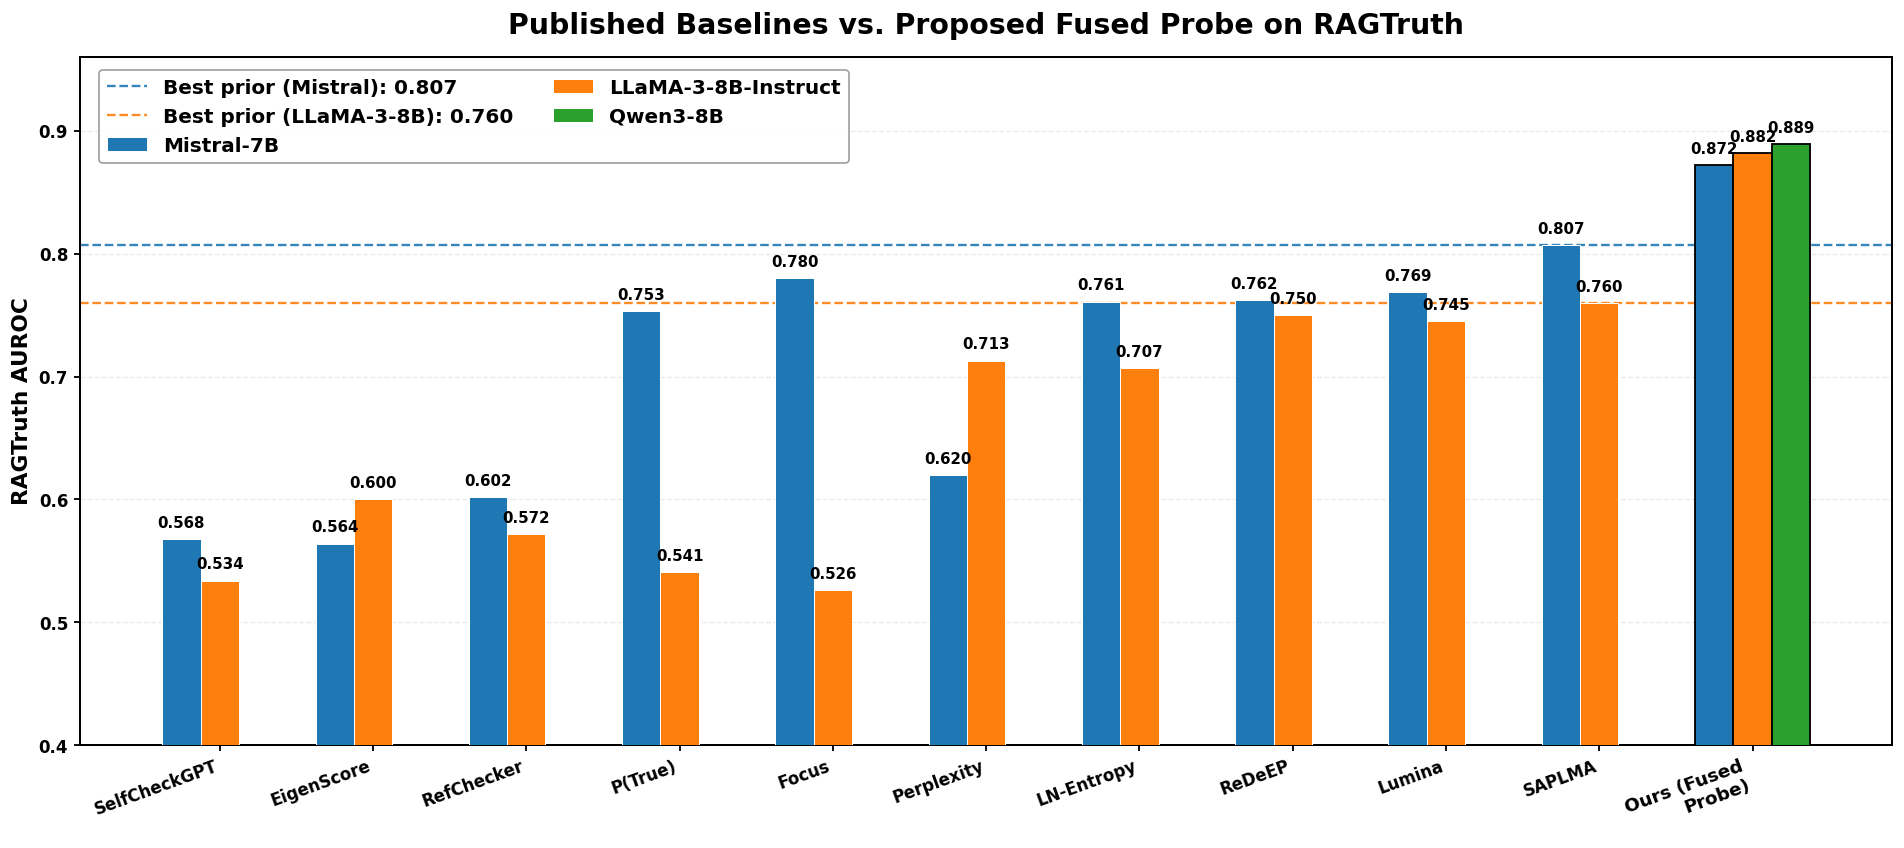

Saved comparison table:
/content/drive/MyDrive/compare_models_controller_v5_current/figures/published_baselines_vs_proposed_fused_probe.csv

Saved 300 dpi figure:
/content/drive/MyDrive/compare_models_controller_v5_current/figures/published_baselines_vs_proposed_fused_probe.png


In [92]:
# ============================================================
# Published Baselines vs Proposed Fused Probe on RAGTruth
# Paper-style grouped bar chart
# ============================================================

from pathlib import Path
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ============================================================
# 1. Output directory
# ============================================================
viz_dir = Path(
    "/content/drive/MyDrive/"
    "compare_models_controller_v5_current/figures"
)

viz_dir.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DPI = 300


# ============================================================
# 2. Published prior-work AUROC values
# ============================================================
prior_work = {
    "SelfCheckGPT": {
        "Mistral-7B-Instruct-v0.2": 0.568,
        "LLaMA-3-8B-Instruct": 0.534,
    },
    "EigenScore": {
        "Mistral-7B-Instruct-v0.2": 0.564,
        "LLaMA-3-8B-Instruct": 0.600,
    },
    "RefChecker": {
        "Mistral-7B-Instruct-v0.2": 0.602,
        "LLaMA-3-8B-Instruct": 0.572,
    },
    "P(True)": {
        "Mistral-7B-Instruct-v0.2": 0.753,
        "LLaMA-3-8B-Instruct": 0.541,
    },
    "Focus": {
        "Mistral-7B-Instruct-v0.2": 0.780,
        "LLaMA-3-8B-Instruct": 0.526,
    },
    "Perplexity": {
        "Mistral-7B-Instruct-v0.2": 0.620,
        "LLaMA-3-8B-Instruct": 0.713,
    },
    "LN-Entropy": {
        "Mistral-7B-Instruct-v0.2": 0.761,
        "LLaMA-3-8B-Instruct": 0.707,
    },
    "ReDeEP": {
        "Mistral-7B-Instruct-v0.2": 0.762,
        "LLaMA-3-8B-Instruct": 0.750,
    },
    "Lumina": {
        "Mistral-7B-Instruct-v0.2": 0.769,
        "LLaMA-3-8B-Instruct": 0.745,
    },
    "SAPLMA": {
        "Mistral-7B-Instruct-v0.2": 0.807,
        "LLaMA-3-8B-Instruct": 0.760,
    },
}


# ============================================================
# 3. Retrieve the proposed fused-probe results
# ============================================================
required_detector_columns = {
    "Backbone",
    "Fused AUROC",
}

missing_detector_columns = (
    required_detector_columns
    - set(detector_df.columns)
)

if missing_detector_columns:
    raise KeyError(
        "detector_df is missing required columns: "
        f"{sorted(missing_detector_columns)}"
    )


ours_map = (
    detector_df
    .set_index("Backbone")["Fused AUROC"]
    .astype(float)
    .to_dict()
)


def get_backbone_result(
    possible_names,
):
    """
    Return the first matching fused AUROC from detector_df.
    This allows small naming differences across notebook versions.
    """
    for backbone_name in possible_names:
        if backbone_name in ours_map:
            return float(
                ours_map[backbone_name]
            )

    raise KeyError(
        "None of these backbone names were found "
        f"in detector_df: {possible_names}. "
        f"Available names: {list(ours_map.keys())}"
    )


mistral_fused_auroc = get_backbone_result([
    "Mistral-7B-Instruct-v0.2",
    "Mistral-7B",
    "Mistral-7B-Instruct",
])

llama_fused_auroc = get_backbone_result([
    "LLaMA-3-8B-Instruct",
    "Llama-3-8B-Instruct",
    "Meta-Llama-3-8B-Instruct",
    "LLaMA-3-8B",
])

qwen_fused_auroc = get_backbone_result([
    "Qwen3-8B",
    "Qwen-3-8B",
    "Qwen/Qwen3-8B",
])


# ============================================================
# 4. Construct the comparison DataFrame
# ============================================================
methods_plot = [
    "SelfCheckGPT",
    "EigenScore",
    "RefChecker",
    "P(True)",
    "Focus",
    "Perplexity",
    "LN-Entropy",
    "ReDeEP",
    "Lumina",
    "SAPLMA",
    "Ours (Fused Probe)",
]


df_prior = pd.DataFrame({
    "Method": methods_plot,

    "mistral-7b": [
        (
            mistral_fused_auroc
            if method_name
            == "Ours (Fused Probe)"
            else prior_work[
                method_name
            ][
                "Mistral-7B-Instruct-v0.2"
            ]
        )
        for method_name
        in methods_plot
    ],

    "llama-3-8b-instruct": [
        (
            llama_fused_auroc
            if method_name
            == "Ours (Fused Probe)"
            else prior_work[
                method_name
            ][
                "LLaMA-3-8B-Instruct"
            ]
        )
        for method_name
        in methods_plot
    ],

    "qwen3-8b": [
        (
            qwen_fused_auroc
            if method_name
            == "Ours (Fused Probe)"
            else np.nan
        )
        for method_name
        in methods_plot
    ],
})


# Display and save the numerical comparison table
comparison_table_path = (
    viz_dir
    / "published_baselines_vs_proposed_fused_probe.csv"
)

df_prior.to_csv(
    comparison_table_path,
    index=False,
)

display(
    df_prior
)


# ============================================================
# 5. Global paper-style plotting configuration
# ============================================================
plt.rcParams.update({
    "font.size": 11,
    "font.weight": "bold",
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.1,
    "ytick.major.width": 1.1,
    "legend.fontsize": 9,
})


# ============================================================
# 6. Create grouped bar chart
# ============================================================
x = np.arange(
    len(methods_plot)
)

bar_width = 0.25

fig, ax = plt.subplots(
    figsize=(16, 7.2)
)


bars_mistral = ax.bar(
    x - bar_width,
    df_prior["mistral-7b"],
    width=bar_width,
    label="Mistral-7B",
    color="#1f77b4",
    edgecolor="white",
    linewidth=0.6,
    zorder=3,
)

bars_llama = ax.bar(
    x,
    df_prior["llama-3-8b-instruct"],
    width=bar_width,
    label="LLaMA-3-8B-Instruct",
    color="#ff7f0e",
    edgecolor="white",
    linewidth=0.6,
    zorder=3,
)

bars_qwen = ax.bar(
    x + bar_width,
    df_prior["qwen3-8b"],
    width=bar_width,
    label="Qwen3-8B",
    color="#2ca02c",
    edgecolor="white",
    linewidth=0.6,
    zorder=3,
)


# ============================================================
# 7. Highlight the proposed fused-probe bars
# ============================================================
ours_index = methods_plot.index(
    "Ours (Fused Probe)"
)

for bars in [
    bars_mistral,
    bars_llama,
    bars_qwen,
]:
    proposed_bar = bars[
        ours_index
    ]

    proposed_bar.set_edgecolor(
        "black"
    )
    proposed_bar.set_linewidth(
        1.1
    )


# ============================================================
# 8. Best published prior baselines
# ============================================================
prior_only = df_prior[
    df_prior["Method"]
    != "Ours (Fused Probe)"
]

best_mistral_prior = float(
    np.nanmax(
        prior_only[
            "mistral-7b"
        ].to_numpy()
    )
)

best_llama_prior = float(
    np.nanmax(
        prior_only[
            "llama-3-8b-instruct"
        ].to_numpy()
    )
)


ax.axhline(
    best_mistral_prior,
    color="#1f77b4",
    linestyle="--",
    linewidth=1.4,
    alpha=0.90,
    label=(
        "Best prior (Mistral): "
        f"{best_mistral_prior:.3f}"
    ),
    zorder=2,
)

ax.axhline(
    best_llama_prior,
    color="#ff7f0e",
    linestyle="--",
    linewidth=1.4,
    alpha=0.90,
    label=(
        "Best prior (LLaMA-3-8B): "
        f"{best_llama_prior:.3f}"
    ),
    zorder=2,
)


# ============================================================
# 9. Add bold value labels
# ============================================================
def label_bars(
    bars,
):
    for bar in bars:
        height = bar.get_height()

        if (
            height is None
            or np.isnan(height)
        ):
            continue

        ax.text(
            (
                bar.get_x()
                + bar.get_width()
                / 2.0
            ),
            min(
                height + 0.007,
                0.944,
            ),
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color="black",
            clip_on=True,
            zorder=4,
        )


label_bars(
    bars_mistral
)

label_bars(
    bars_llama
)

label_bars(
    bars_qwen
)


# ============================================================
# 10. Axis labels and formatting
# ============================================================
wrapped_method_labels = [
    textwrap.fill(
        method_name,
        width=13,
    )
    for method_name
    in methods_plot
]


ax.set_xticks(
    x
)

ax.set_xticklabels(
    wrapped_method_labels,
    rotation=20,
    ha="right",
    fontsize=10,
    fontweight="bold",
)


for tick_label, method_name in zip(
    ax.get_xticklabels(),
    methods_plot,
):
    if method_name == "Ours (Fused Probe)":
        tick_label.set_fontweight(
            "bold"
        )
        tick_label.set_fontsize(
            11
        )


ax.set_ylabel(
    "RAGTruth AUROC",
    fontsize=13,
    fontweight="bold",
)

ax.set_ylim(
    0.40,
    0.96,
)

ax.set_title(
    (
        "Published Baselines vs. Proposed "
        "Fused Probe on RAGTruth"
    ),
    fontsize=17,
    fontweight="bold",
    pad=14,
)


ax.grid(
    True,
    axis="y",
    alpha=0.28,
    linestyle="--",
    linewidth=0.8,
    zorder=0,
)

ax.set_axisbelow(
    True
)


for tick_label in ax.get_yticklabels():
    tick_label.set_fontweight(
        "bold"
    )
    tick_label.set_fontsize(
        10
    )


# ============================================================
# 11. Legend
# ============================================================
legend = ax.legend(
    loc="upper left",
    bbox_to_anchor=(
        0.005,
        0.995,
    ),
    ncol=2,
    fontsize=12,
    frameon=True,
    framealpha=0.95,
    edgecolor="#999999",
)


for legend_text in legend.get_texts():
    legend_text.set_fontweight(
        "bold"
    )


# ============================================================
# 12. Save at 300 dpi
# ============================================================
fig.tight_layout()

figure_path = (
    viz_dir
    / "published_baselines_vs_proposed_fused_probe.png"
)

fig.savefig(
    figure_path,
    dpi=FIGURE_DPI,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()
plt.close(
    fig
)


print(
    "Saved comparison table:"
)
print(
    comparison_table_path
)

print(
    "\nSaved 300 dpi figure:"
)
print(
    figure_path
)

## 10. RAGTruth versus HaluEval fused AUROC

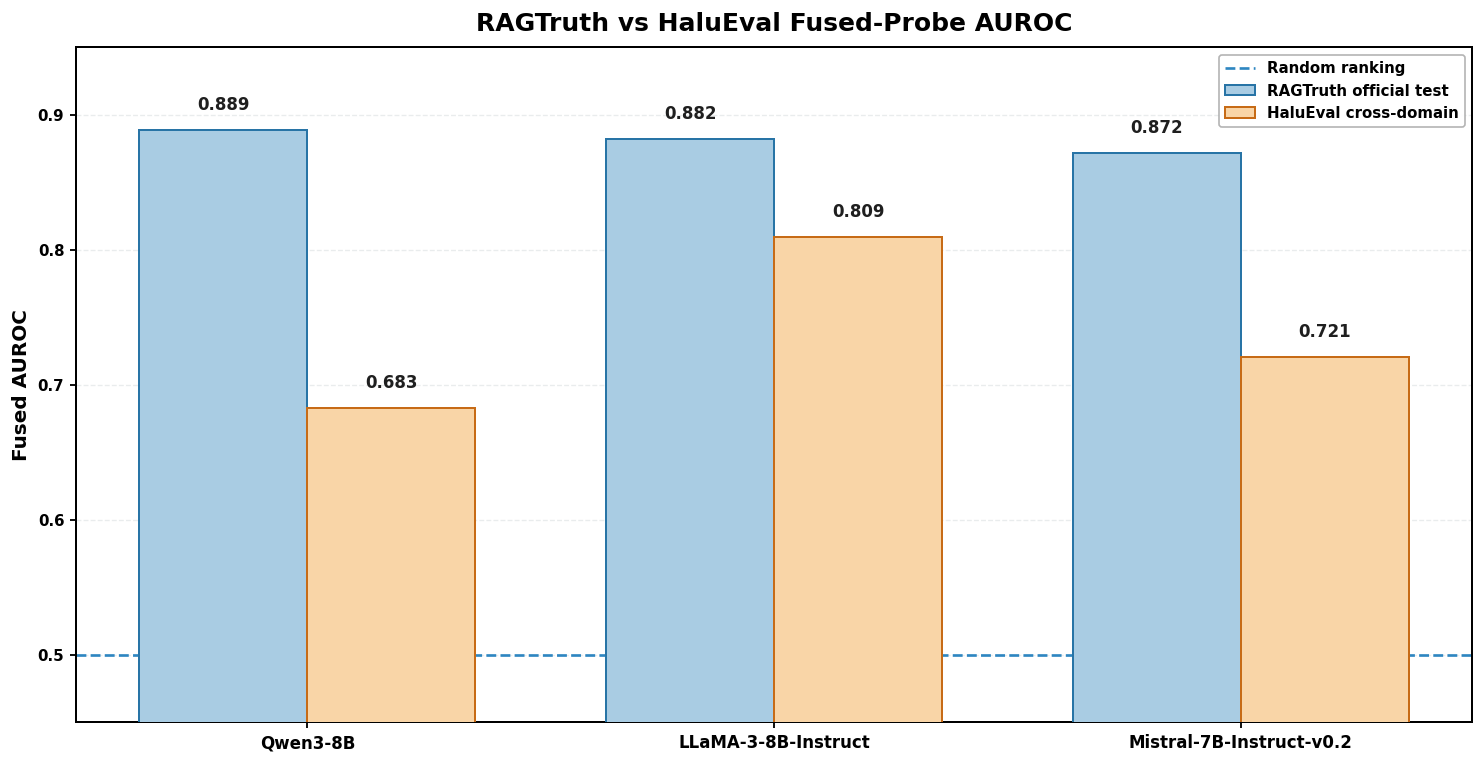

Saved: /content/drive/MyDrive/compare_models_controller_v5_current/figures/ragtruth_vs_halueval_fused_auroc.png


In [93]:
# ============================================================
# RAGTruth vs HaluEval Fused-Probe AUROC
# Light pastel paper-friendly version
# ============================================================

import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# 1. Extract fused AUROC values
# ============================================================
ragtruth_fused = (
    detector_df
    .set_index("Backbone")
    .loc[
        MODEL_ORDER,
        "Fused AUROC",
    ]
    .to_numpy(
        dtype=float
    )
)

halueval_fused = (
    halueval_df
    .set_index("Backbone")
    .loc[
        MODEL_ORDER,
        "Fused AUROC",
    ]
    .to_numpy(
        dtype=float
    )
)

x = np.arange(
    len(MODEL_ORDER)
)

width = 0.36


# ============================================================
# 2. Light pastel colors
# ============================================================
RAGTRUTH_COLOR = "#A9CCE3"      # light pastel blue
HALUEVAL_COLOR = "#F9D5A7"      # light pastel orange

RAGTRUTH_EDGE = "#2874A6"       # darker blue border
HALUEVAL_EDGE = "#C76B16"       # darker orange border

RANDOM_LINE_COLOR = "#2E86C1"   # blue dashed reference line


# ============================================================
# 3. Create figure
# ============================================================
fig, axis = plt.subplots(
    figsize=(12.5, 6.5)
)


# ============================================================
# 4. Draw grouped bars
# ============================================================
bars_in = axis.bar(
    x - width / 2.0,
    ragtruth_fused,
    width,
    label="RAGTruth official test",
    color=RAGTRUTH_COLOR,
    edgecolor=RAGTRUTH_EDGE,
    linewidth=1.2,
    zorder=3,
)

bars_cross = axis.bar(
    x + width / 2.0,
    halueval_fused,
    width,
    label="HaluEval cross-domain",
    color=HALUEVAL_COLOR,
    edgecolor=HALUEVAL_EDGE,
    linewidth=1.2,
    zorder=3,
)


# ============================================================
# 5. Add value labels
# ============================================================
for bars in (
    bars_in,
    bars_cross,
):
    for bar in bars:
        value = bar.get_height()

        axis.text(
            bar.get_x()
            + bar.get_width()
            / 2.0,
            value + 0.012,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color="#1F1F1F",
            zorder=4,
        )


# ============================================================
# 6. Random-ranking reference line
# ============================================================
axis.axhline(
    0.5,
    color=RANDOM_LINE_COLOR,
    linestyle="--",
    linewidth=1.6,
    label="Random ranking",
    zorder=2,
)


# ============================================================
# 7. Axis formatting
# ============================================================
axis.set_xticks(
    x
)

axis.set_xticklabels(
    MODEL_ORDER,
    fontsize=10,
    fontweight="bold",
)

axis.set_ylim(
    0.45,
    0.95,
)

axis.set_ylabel(
    "Fused AUROC",
    fontsize=12,
    fontweight="bold",
)

axis.set_title(
    "RAGTruth vs HaluEval Fused-Probe AUROC",
    fontsize=15,
    fontweight="bold",
    pad=10,
)

axis.grid(
    axis="y",
    alpha=0.25,
    linestyle="--",
    linewidth=0.8,
    color="#AAB7B8",
    zorder=0,
)

axis.set_axisbelow(
    True
)

for tick_label in axis.get_yticklabels():
    tick_label.set_fontweight(
        "bold"
    )
    tick_label.set_fontsize(
        9
    )


# ============================================================
# 8. Legend
# ============================================================
legend = axis.legend(
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="#B0B0B0",
    framealpha=0.95,
    fontsize=9,
)

for legend_text in legend.get_texts():
    legend_text.set_fontweight(
        "bold"
    )


# ============================================================
# 9. Save figure
# ============================================================
fig.tight_layout()

ragtruth_halueval_figure = save_figure(
    fig,
    "ragtruth_vs_halueval_fused_auroc.png",
)

## 11. Final Controller-v5 safety–quality profile

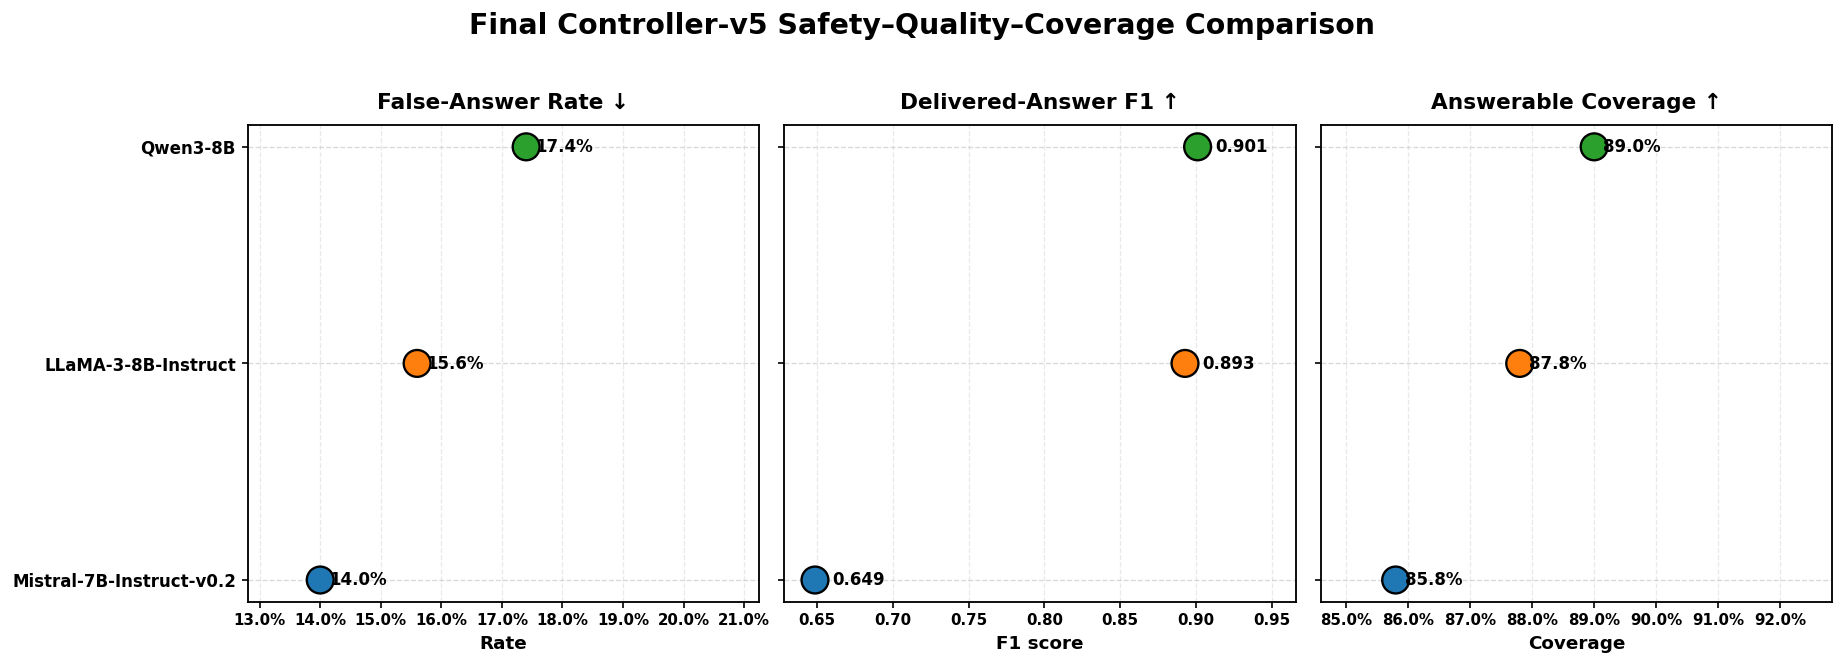

Saved 300 dpi figure:
/content/drive/MyDrive/compare_models_controller_v5_current/figures/controller_v5_safety_quality_coverage_dotplot.png


In [94]:
# ============================================================
# Controller-v5 Safety, Quality, and Coverage Comparison
# Three-metric horizontal dot plot
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter


# ============================================================
# 1. Prepare model results
# ============================================================
profile_frame = (
    controller_df
    .set_index("Backbone")
    .loc[MODEL_ORDER]
    .reset_index()
)

required_columns = {
    "Backbone",
    "Controller false-answer rate",
    "Answerable F1 — delivered",
    "Answerable coverage",
}

missing_columns = (
    required_columns
    - set(profile_frame.columns)
)

if missing_columns:
    raise KeyError(
        "controller_df is missing required columns: "
        f"{sorted(missing_columns)}"
    )


# ============================================================
# 2. Output directory
# ============================================================
viz_dir = Path(
    "/content/drive/MyDrive/"
    "compare_models_controller_v5_current/figures"
)

viz_dir.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DPI = 300


# ============================================================
# 3. Consistent model colors
# ============================================================
model_colors = {
    "Mistral-7B-Instruct-v0.2": "#1f77b4",
    "LLaMA-3-8B-Instruct": "#ff7f0e",
    "Qwen3-8B": "#2ca02c",
}

fallback_colors = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
]

point_colors = [
    model_colors.get(
        backbone,
        fallback_colors[index % len(fallback_colors)],
    )
    for index, backbone
    in enumerate(profile_frame["Backbone"])
]


# ============================================================
# 4. Global paper-style formatting
# ============================================================
plt.rcParams.update({
    "font.size": 11,
    "font.weight": "bold",
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.linewidth": 1.1,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
})


# ============================================================
# 5. Create the three-metric dot plot
# ============================================================
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15.5, 5.4),
    sharey=True,
)

y_positions = np.arange(
    len(profile_frame)
)


metrics = [
    {
        "column": "Controller false-answer rate",
        "title": "False-Answer Rate ↓",
        "xlabel": "Rate",
        "formatter": "percent",
        "lower_is_better": True,
    },
    {
        "column": "Answerable F1 — delivered",
        "title": "Delivered-Answer F1 ↑",
        "xlabel": "F1 score",
        "formatter": "decimal",
        "lower_is_better": False,
    },
    {
        "column": "Answerable coverage",
        "title": "Answerable Coverage ↑",
        "xlabel": "Coverage",
        "formatter": "percent",
        "lower_is_better": False,
    },
]


for axis, metric in zip(
    axes,
    metrics,
):
    values = profile_frame[
        metric["column"]
    ].to_numpy(
        dtype=float
    )

    axis.scatter(
        values,
        y_positions,
        s=260,
        c=point_colors,
        edgecolors="black",
        linewidths=1.4,
        zorder=3,
    )

    # Draw a faint horizontal guide for each model.
    for y_position in y_positions:
        axis.axhline(
            y=y_position,
            color="#d9d9d9",
            linewidth=0.8,
            linestyle="--",
            zorder=0,
        )

    # Add values beside each point.
    value_range = max(
        float(values.max() - values.min()),
        0.01,
    )

    label_offset = (
        0.045 * value_range
    )

    for y_position, value in zip(
        y_positions,
        values,
    ):
        if metric["formatter"] == "percent":
            value_label = f"{value:.1%}"
        else:
            value_label = f"{value:.3f}"

        axis.text(
            value + label_offset,
            y_position,
            value_label,
            va="center",
            ha="left",
            fontsize=10,
            fontweight="bold",
            color="black",
        )

    # Add compact axis padding.
    minimum_value = float(
        values.min()
    )
    maximum_value = float(
        values.max()
    )

    padding = max(
        0.08 * (
            maximum_value
            - minimum_value
        ),
        0.012,
    )

    axis.set_xlim(
        minimum_value - padding,
        maximum_value + 3.2 * padding,
    )

    axis.set_title(
        metric["title"],
        fontsize=13,
        fontweight="bold",
        pad=10,
    )

    axis.set_xlabel(
        metric["xlabel"],
        fontsize=11,
        fontweight="bold",
    )

    axis.grid(
        axis="x",
        alpha=0.28,
        linestyle="--",
        linewidth=0.8,
    )

    axis.set_axisbelow(
        True
    )

    if metric["formatter"] == "percent":
        axis.xaxis.set_major_formatter(
            PercentFormatter(
                1.0
            )
        )

    for tick_label in axis.get_xticklabels():
        tick_label.set_fontweight(
            "bold"
        )
        tick_label.set_fontsize(
            9
        )


# ============================================================
# 6. Model labels
# ============================================================
axes[0].set_yticks(
    y_positions
)

axes[0].set_yticklabels(
    profile_frame["Backbone"],
    fontsize=10,
    fontweight="bold",
)

# Place the strongest visual row at the top.
axes[0].invert_yaxis()


# ============================================================
# 7. Main title
# ============================================================
fig.suptitle(
    "Final Controller-v5 Safety–Quality–Coverage Comparison",
    fontsize=17,
    fontweight="bold",
    y=1.02,
)

fig.tight_layout()


# ============================================================
# 8. Save at 300 dpi
# ============================================================
figure_path = (
    viz_dir
    / "controller_v5_safety_quality_coverage_dotplot.png"
)

fig.savefig(
    figure_path,
    dpi=FIGURE_DPI,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()
plt.close(
    fig
)

print(
    "Saved 300 dpi figure:"
)
print(
    figure_path
)

## 12. Probe training curves

The grid shows mean out-of-fold training loss and validation AUROC. Only epochs
represented by at least two folds are displayed, preserving a consistent
cross-fold comparison.

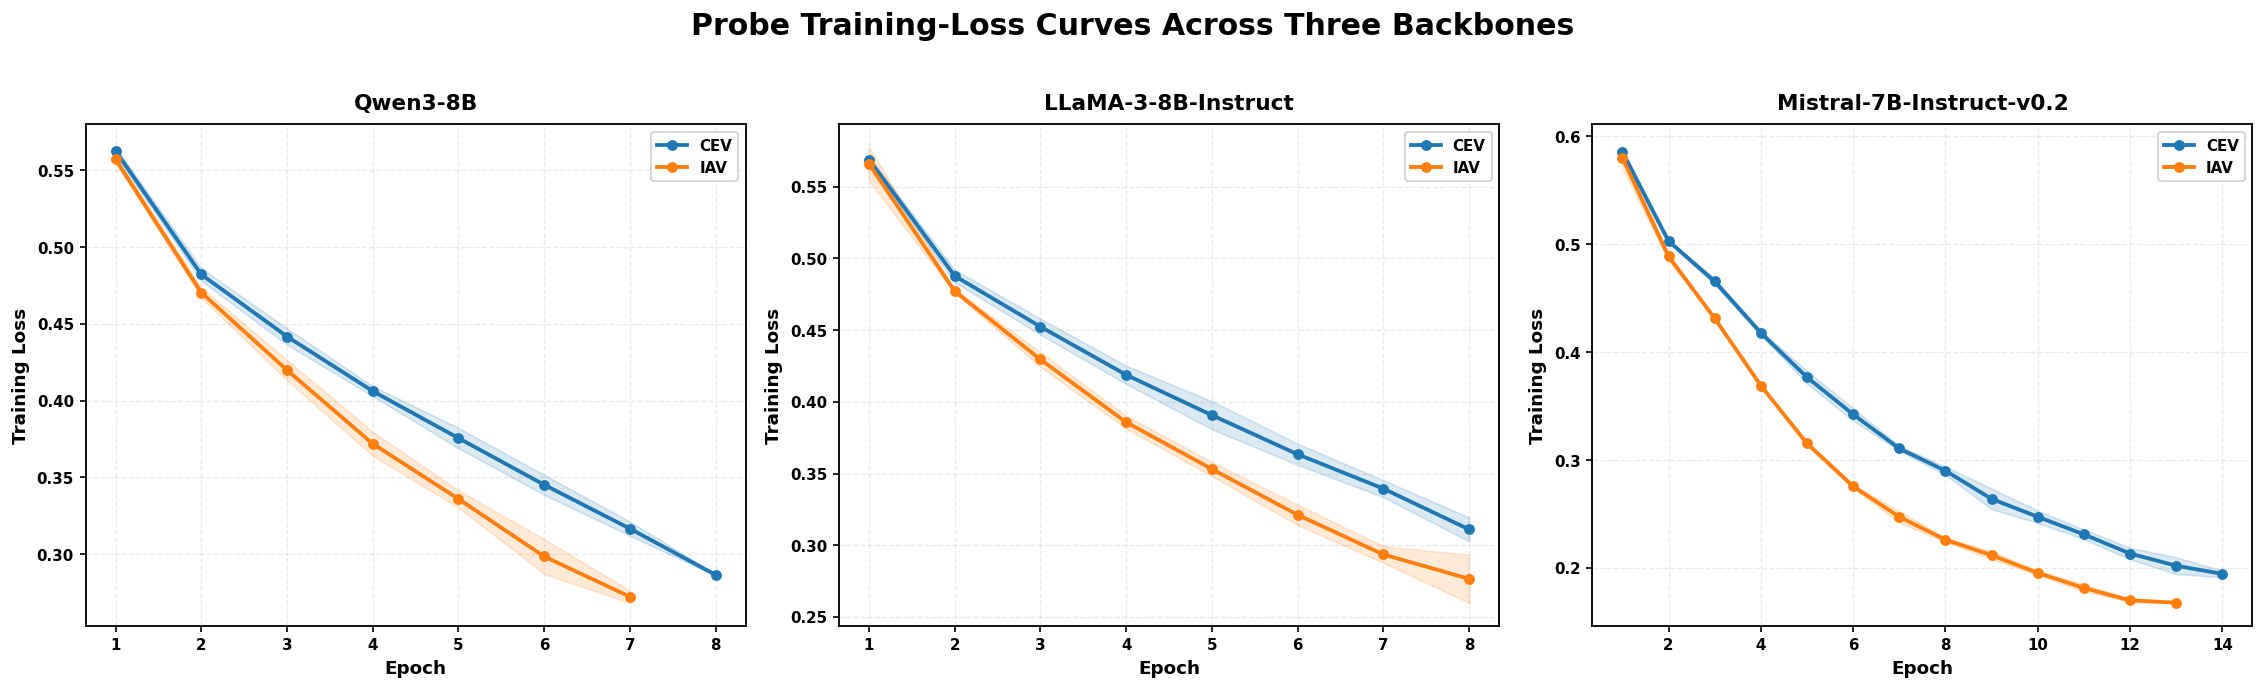

Saved: /content/drive/MyDrive/compare_models_controller_v5_current/figures/probe_training_curves_three_backbones.png


In [95]:
# ============================================================
# Probe Training-Loss Curves Across Three Backbones
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(19, 5.6),
    sharex=False,
    sharey=False,
)

for column_index, model_name in enumerate(
    MODEL_ORDER
):
    history = training_histories[
        model_name
    ].copy()

    # Only the columns required for training-loss visualization.
    required_columns = {
        "branch",
        "epoch",
        "train_loss_mean",
        "train_loss_std",
        "contributing_folds",
    }

    missing_columns = (
        required_columns
        - set(
            history.columns
        )
    )

    if missing_columns:
        raise RuntimeError(
            f"{model_name} training history "
            f"is missing: {sorted(missing_columns)}"
        )

    # Retain epochs represented by at least two folds.
    history = history[
        history[
            "contributing_folds"
        ]
        >= 2
    ].copy()

    axis = axes[
        column_index
    ]

    for branch_name in (
        "CEV",
        "IAV",
    ):
        branch = (
            history[
                history[
                    "branch"
                ]
                == branch_name
            ]
            .sort_values(
                "epoch"
            )
        )

        if branch.empty:
            raise RuntimeError(
                f"No {branch_name} training-history rows "
                f"were found for {model_name}."
            )

        epoch = branch[
            "epoch"
        ].to_numpy(
            dtype=float
        )

        loss_mean = branch[
            "train_loss_mean"
        ].to_numpy(
            dtype=float
        )

        loss_std = branch[
            "train_loss_std"
        ].fillna(
            0.0
        ).to_numpy(
            dtype=float
        )

        loss_line = axis.plot(
            epoch,
            loss_mean,
            marker="o",
            markersize=5.5,
            linewidth=2.3,
            label=branch_name,
        )[0]

        axis.fill_between(
            epoch,
            loss_mean - loss_std,
            loss_mean + loss_std,
            alpha=0.16,
            color=loss_line.get_color(),
        )

    axis.set_title(
        model_name,
        fontsize=13,
        fontweight="bold",
        pad=9,
    )

    axis.set_xlabel(
        "Epoch",
        fontsize=11,
        fontweight="bold",
    )

    axis.set_ylabel(
        "Training Loss",
        fontsize=11,
        fontweight="bold",
    )

    axis.tick_params(
        axis="both",
        labelsize=9,
        width=1.0,
    )

    for tick_label in (
        axis.get_xticklabels()
        + axis.get_yticklabels()
    ):
        tick_label.set_fontweight(
            "bold"
        )

    axis.grid(
        True,
        alpha=0.28,
        linestyle="--",
        linewidth=0.8,
    )

    axis.set_axisbelow(
        True
    )

    axis.legend(
        frameon=True,
        framealpha=0.92,
        fontsize=9,
        prop={
            "weight": "bold",
            "size": 9,
        },
    )

fig.suptitle(
    "Probe Training-Loss Curves Across Three Backbones",
    fontsize=18,
    fontweight="bold",
    y=1.02,
)

fig.tight_layout()

# Keep the existing filename so the final verification cell
# does not need to be changed.
training_curve_figure = save_figure(
    fig,
    "probe_training_curves_three_backbones.png",
)

## 13. HaluEval ROC grid

Raw scores are the primary cross-domain result. A dashed diagnostic flipped
curve is added only when a branch has raw AUROC below 0.5. Under the current
finalized runs, Mistral does **not** require polarity inversion.

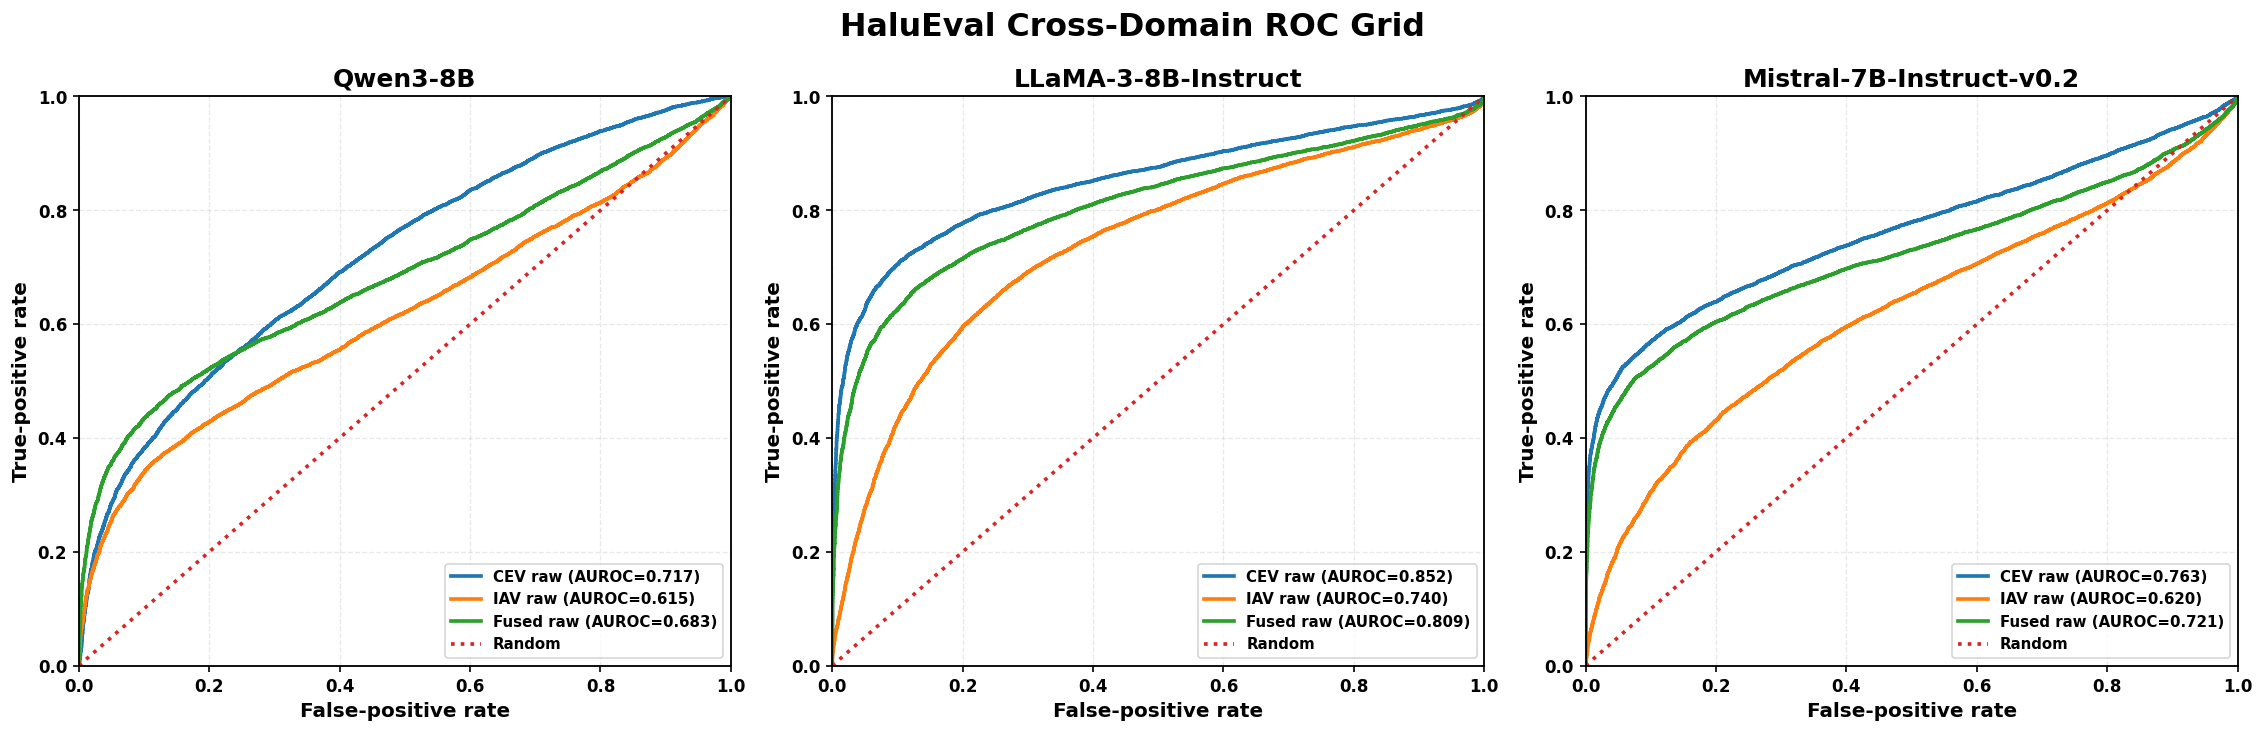

Saved: /content/drive/MyDrive/compare_models_controller_v5_current/figures/halueval_roc_grid.png


In [96]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(19, 6.2),
)

for axis, model_name in zip(
    axes,
    MODEL_ORDER,
):
    predictions = loaded[
        model_name
    ][
        "halueval_predictions"
    ].copy()

    # Determine column mapping based on available columns
    # Mistral uses '_raw' suffix while others use standard names
    if "cev_probability_raw" in predictions.columns:
        signal_columns = {
            "CEV": "cev_probability_raw",
            "IAV": "iav_probability_raw",
            "Fused": "fused_probability_raw",
        }
    else:
        signal_columns = {
            "CEV": "cev_probability",
            "IAV": "iav_probability",
            "Fused": "fused_probability",
        }

    required_columns = {"label"} | set(signal_columns.values())
    missing_columns = required_columns - set(predictions.columns)

    if missing_columns:
        raise RuntimeError(
            f"{model_name} HaluEval predictions "
            f"are missing: {sorted(missing_columns)}"
        )

    labels = predictions[
        "label"
    ].astype(int).to_numpy()

    for display_name, column_name in signal_columns.items():
        scores = predictions[
            column_name
        ].to_numpy(
            dtype=float
        )

        raw_auc = roc_auc_score(
            labels,
            scores,
        )
        false_positive_rate, true_positive_rate, _ = roc_curve(
            labels,
            scores,
        )

        raw_line = axis.plot(
            false_positive_rate,
            true_positive_rate,
            label=(
                f"{display_name} raw "
                f"(AUROC={raw_auc:.3f})"
            ),
        )[0]

        if raw_auc < 0.5:
            flipped_scores = (
                1.0
                - scores
            )
            flipped_auc = roc_auc_score(
                labels,
                flipped_scores,
            )
            flipped_fpr, flipped_tpr, _ = roc_curve(
                labels,
                flipped_scores,
            )
            axis.plot(
                flipped_fpr,
                flipped_tpr,
                linestyle="--",
                color=raw_line.get_color(),
                label=(
                    f"{display_name} flipped diagnostic "
                    f"(AUROC={flipped_auc:.3f})"
                ),
            )

    axis.plot(
        [
            0.0,
            1.0,
        ],
        [
            0.0,
            1.0,
        ],
        linestyle=":",
        label="Random",
    )
    axis.set_xlim(
        0.0,
        1.0,
    )
    axis.set_ylim(
        0.0,
        1.0,
    )
    axis.set_xlabel(
        "False-positive rate",
        fontweight="bold",
    )
    axis.set_ylabel(
        "True-positive rate",
        fontweight="bold",
    )
    axis.set_title(
        model_name,
        fontweight="bold",
    )
    axis.grid(
        alpha=0.28,
        linestyle="--",
    )
    axis.legend(
        loc="lower right",
        frameon=True,
        fontsize=9,
    )

fig.suptitle(
    "HaluEval Cross-Domain ROC Grid",
    fontsize=19,
    fontweight="bold",
)
fig.tight_layout()

halueval_roc_figure = save_figure(
    fig,
    "halueval_roc_grid.png",
)

## 14. Vanilla RAG vs Closed-Loop RAG Comparison

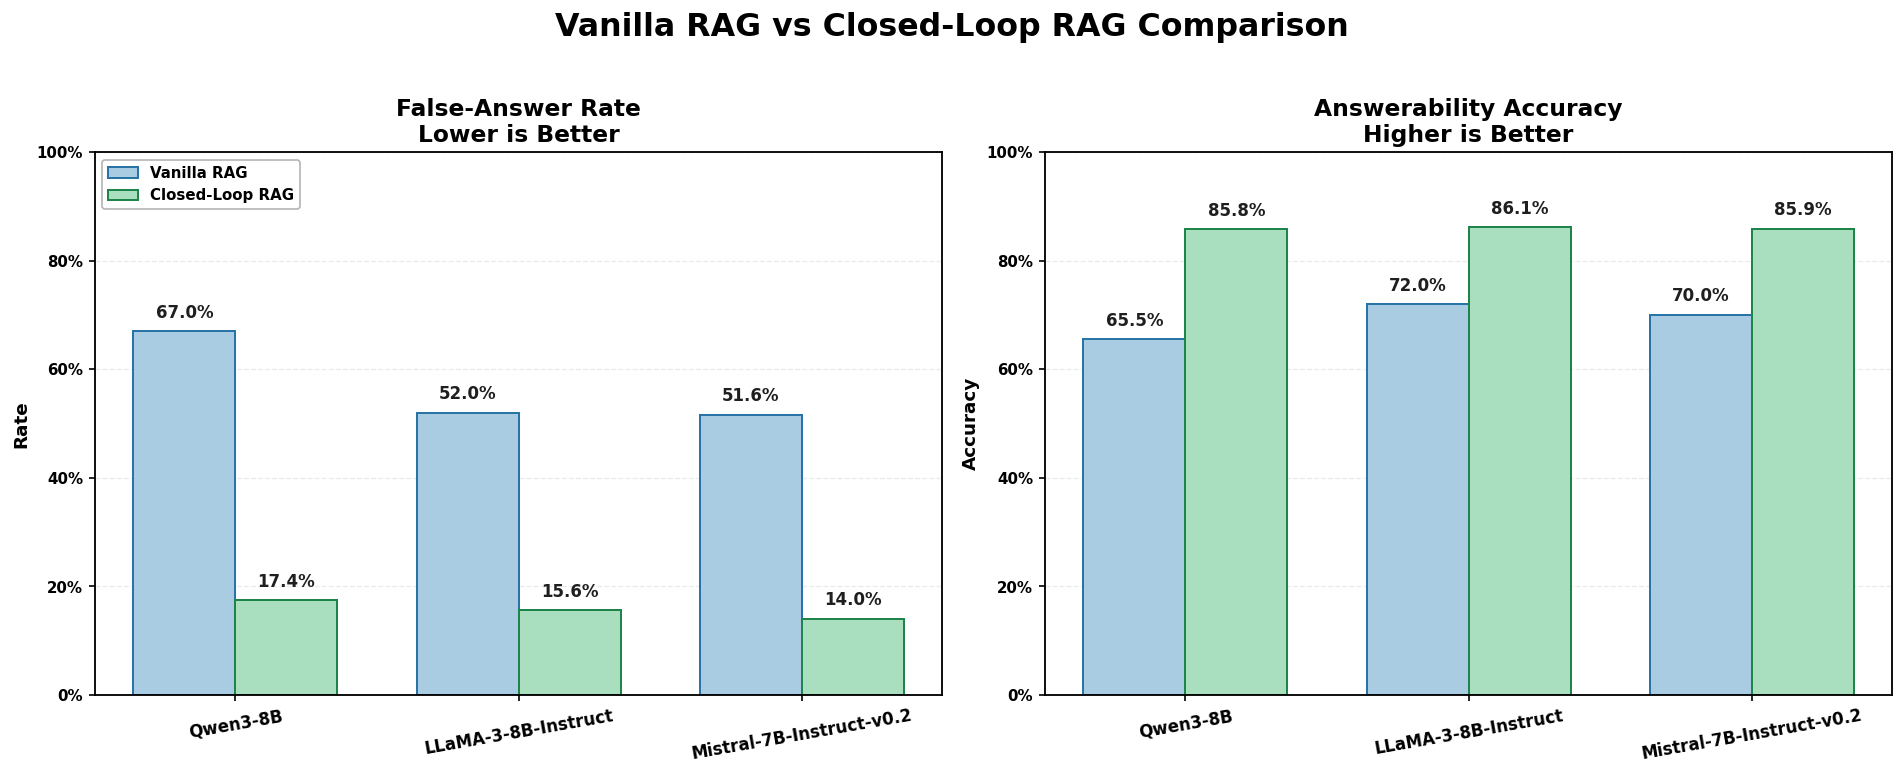

Saved: /content/drive/MyDrive/compare_models_controller_v5_current/figures/vanilla_rag_vs_closed_loop_rag.png


In [97]:
# ============================================================
# Vanilla RAG vs Closed-Loop RAG Comparison
# Light pastel color version
# Legend shown only in the False-Answer Rate panel
# ============================================================

from matplotlib.ticker import PercentFormatter
import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# 1. Prepare comparison data
# ============================================================
comparison_frame = (
    controller_df
    .set_index("Backbone")
    .loc[MODEL_ORDER]
)

x = np.arange(
    len(MODEL_ORDER)
)

width = 0.36


# ============================================================
# 2. Light paper-friendly colors
# ============================================================
VANILLA_COLOR = "#A9CCE3"       # light blue
CLOSED_LOOP_COLOR = "#A9DFBF"   # light green

VANILLA_EDGE = "#2874A6"        # darker blue border
CLOSED_LOOP_EDGE = "#1E8449"    # darker green border


# ============================================================
# 3. Create figure
# ============================================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6.3),
)


# ============================================================
# 4. False-answer rate comparison
# ============================================================
vanilla_far = comparison_frame[
    "Vanilla false-answer rate"
].to_numpy(
    dtype=float
)

controller_far = comparison_frame[
    "Controller false-answer rate"
].to_numpy(
    dtype=float
)


far_vanilla_bars = axes[0].bar(
    x - width / 2.0,
    vanilla_far,
    width,
    label="Vanilla RAG",
    color=VANILLA_COLOR,
    edgecolor=VANILLA_EDGE,
    linewidth=1.2,
)

far_controller_bars = axes[0].bar(
    x + width / 2.0,
    controller_far,
    width,
    label="Closed-Loop RAG",
    color=CLOSED_LOOP_COLOR,
    edgecolor=CLOSED_LOOP_EDGE,
    linewidth=1.2,
)


# ============================================================
# 5. Answerability accuracy comparison
# ============================================================
vanilla_accuracy = comparison_frame[
    "Vanilla answerability accuracy"
].to_numpy(
    dtype=float
)

controller_accuracy = comparison_frame[
    "Controller answerability accuracy"
].to_numpy(
    dtype=float
)


accuracy_vanilla_bars = axes[1].bar(
    x - width / 2.0,
    vanilla_accuracy,
    width,
    color=VANILLA_COLOR,
    edgecolor=VANILLA_EDGE,
    linewidth=1.2,
)

accuracy_controller_bars = axes[1].bar(
    x + width / 2.0,
    controller_accuracy,
    width,
    color=CLOSED_LOOP_COLOR,
    edgecolor=CLOSED_LOOP_EDGE,
    linewidth=1.2,
)


# ============================================================
# 6. Shared formatting and value labels
# ============================================================
for axis, bar_groups in (
    (
        axes[0],
        (
            far_vanilla_bars,
            far_controller_bars,
        ),
    ),
    (
        axes[1],
        (
            accuracy_vanilla_bars,
            accuracy_controller_bars,
        ),
    ),
):
    for bars in bar_groups:
        for bar in bars:
            value = bar.get_height()

            axis.text(
                bar.get_x()
                + bar.get_width()
                / 2.0,
                value + 0.018,
                f"{value:.1%}",
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold",
                color="#1F1F1F",
            )

    axis.set_xticks(
        x
    )

    axis.set_xticklabels(
        MODEL_ORDER,
        rotation=10,
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

    axis.set_ylim(
        0.0,
        1.0,
    )

    axis.yaxis.set_major_formatter(
        PercentFormatter(
            1.0
        )
    )

    axis.grid(
        axis="y",
        alpha=0.25,
        linestyle="--",
        linewidth=0.8,
        color="#AAB7B8",
    )

    axis.set_axisbelow(
        True
    )

    for tick_label in axis.get_yticklabels():
        tick_label.set_fontweight(
            "bold"
        )

        tick_label.set_fontsize(
            9
        )


# ============================================================
# 7. Legend only for the False-Answer Rate panel
# ============================================================
legend = axes[0].legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="#B0B0B0",
    framealpha=0.95,
    fontsize=9,
)

for legend_text in legend.get_texts():
    legend_text.set_fontweight(
        "bold"
    )


# ============================================================
# 8. Panel titles and labels
# ============================================================
axes[0].set_title(
    "False-Answer Rate\nLower is Better",
    fontsize=14,
    fontweight="bold",
)

axes[0].set_ylabel(
    "Rate",
    fontsize=11,
    fontweight="bold",
)


axes[1].set_title(
    "Answerability Accuracy\nHigher is Better",
    fontsize=14,
    fontweight="bold",
)

axes[1].set_ylabel(
    "Accuracy",
    fontsize=11,
    fontweight="bold",
)


# ============================================================
# 9. Main title
# ============================================================
fig.suptitle(
    "Vanilla RAG vs Closed-Loop RAG Comparison",
    fontsize=19,
    fontweight="bold",
    y=1.02,
)

fig.tight_layout()


# ============================================================
# 10. Save figure
# ============================================================
vanilla_closed_loop_figure = save_figure(
    fig,
    "vanilla_rag_vs_closed_loop_rag.png",
)

## 15. CEV, IAV, and fused-probe comparison

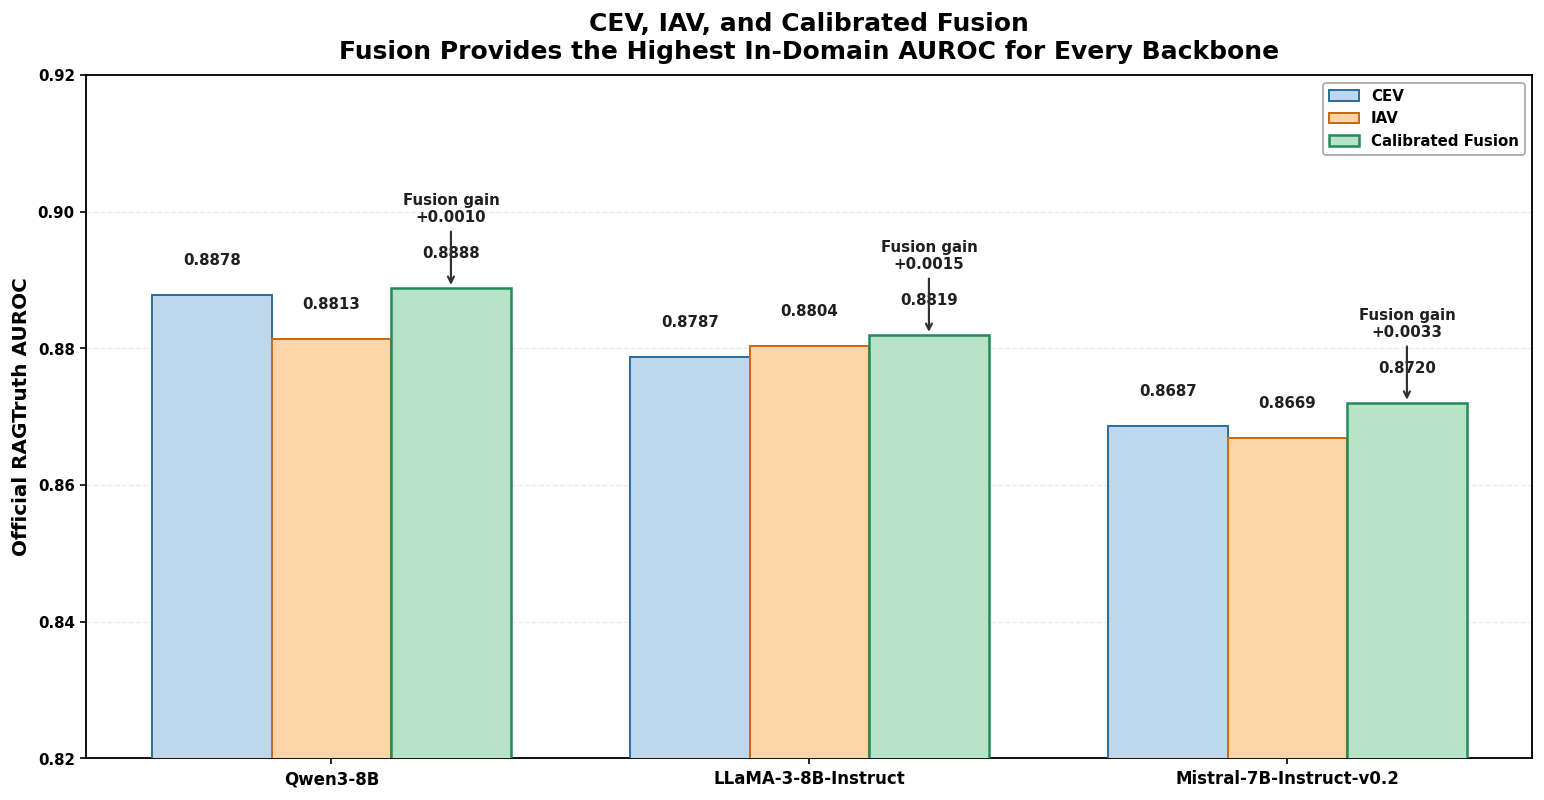

Saved: /content/drive/MyDrive/compare_models_controller_v5_current/figures/cev_iav_fused_probe_comparison.png


In [98]:
# ============================================================
# CEV, IAV, and Calibrated Fusion Comparison
# Light pastel paper-friendly version
# ============================================================

import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# 1. Prepare detector results
# ============================================================
probe_frame = (
    detector_df
    .set_index("Backbone")
    .loc[MODEL_ORDER]
)

x = np.arange(
    len(MODEL_ORDER)
)

width = 0.25


# ============================================================
# 2. Light pastel colors with darker borders
# ============================================================
CEV_COLOR = "#BFD7EA"       # light pastel blue
IAV_COLOR = "#F9D5A7"       # light pastel orange
FUSION_COLOR = "#B7E4C7"    # light pastel green

CEV_EDGE = "#2E6F9E"        # dark blue border
IAV_EDGE = "#C76B16"        # dark orange border
FUSION_EDGE = "#238B57"     # dark green border


# ============================================================
# 3. Extract AUROC values
# ============================================================
cev_values = probe_frame[
    "CEV AUROC"
].to_numpy(
    dtype=float
)

iav_values = probe_frame[
    "IAV AUROC"
].to_numpy(
    dtype=float
)

fused_values = probe_frame[
    "Fused AUROC"
].to_numpy(
    dtype=float
)


# ============================================================
# 4. Create figure
# ============================================================
fig, axis = plt.subplots(
    figsize=(13, 6.8)
)


# ============================================================
# 5. Draw grouped bars
# ============================================================
cev_bars = axis.bar(
    x - width,
    cev_values,
    width,
    label="CEV",
    color=CEV_COLOR,
    edgecolor=CEV_EDGE,
    linewidth=1.2,
    zorder=3,
)

iav_bars = axis.bar(
    x,
    iav_values,
    width,
    label="IAV",
    color=IAV_COLOR,
    edgecolor=IAV_EDGE,
    linewidth=1.2,
    zorder=3,
)

fused_bars = axis.bar(
    x + width,
    fused_values,
    width,
    label="Calibrated Fusion",
    color=FUSION_COLOR,
    edgecolor=FUSION_EDGE,
    linewidth=1.5,
    zorder=3,
)


# ============================================================
# 6. Add AUROC value labels
# ============================================================
for bars in (
    cev_bars,
    iav_bars,
    fused_bars,
):
    for bar in bars:
        value = bar.get_height()

        axis.text(
            bar.get_x()
            + bar.get_width()
            / 2.0,
            value + 0.004,
            f"{value:.4f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color="#202020",
            zorder=4,
        )


# ============================================================
# 7. Add fusion-gain annotations
# ============================================================
for model_index, model_name in enumerate(
    MODEL_ORDER
):
    best_branch = max(
        cev_values[
            model_index
        ],
        iav_values[
            model_index
        ],
    )

    fusion_gain = (
        fused_values[
            model_index
        ]
        - best_branch
    )

    axis.annotate(
        (
            "Fusion gain\n"
            f"{fusion_gain:+.4f}"
        ),
        xy=(
            x[
                model_index
            ]
            + width,
            fused_values[
                model_index
            ],
        ),
        xytext=(
            0,
            38,
        ),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#202020",
        arrowprops={
            "arrowstyle": "->",
            "linewidth": 1.3,
            "color": "#303030",
        },
        zorder=5,
    )


# ============================================================
# 8. Axis formatting
# ============================================================
axis.set_xticks(
    x
)

axis.set_xticklabels(
    MODEL_ORDER,
    fontsize=10,
    fontweight="bold",
)

axis.set_ylim(
    0.82,
    0.92,
)

axis.set_ylabel(
    "Official RAGTruth AUROC",
    fontsize=12,
    fontweight="bold",
)

axis.set_title(
    (
        "CEV, IAV, and Calibrated Fusion\n"
        "Fusion Provides the Highest In-Domain AUROC "
        "for Every Backbone"
    ),
    fontsize=15,
    fontweight="bold",
    pad=10,
)

axis.grid(
    axis="y",
    alpha=0.25,
    linestyle="--",
    linewidth=0.8,
    color="#AAB7B8",
    zorder=0,
)

axis.set_axisbelow(
    True
)


# Make tick labels bold
for tick_label in axis.get_yticklabels():
    tick_label.set_fontweight(
        "bold"
    )
    tick_label.set_fontsize(
        9
    )


# ============================================================
# 9. Legend
# ============================================================
legend = axis.legend(
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="#A0A0A0",
    framealpha=0.95,
    fontsize=9,
)

for legend_text in legend.get_texts():
    legend_text.set_fontweight(
        "bold"
    )


# ============================================================
# 10. Save figure
# ============================================================
fig.tight_layout()

probe_comparison_figure = save_figure(
    fig,
    "cev_iav_fused_probe_comparison.png",
)

## 16. Final verification of the current three-backbone comparison

In [99]:
REQUIRED_TABLE_FILES = [
    "artifact_validation.csv",
    "official_ragtruth_detector_comparison.csv",
    "final_controller_safety_utility_comparison.csv",
    "latency_and_controller_action_comparison.csv",
    "cross_model_best_outcomes.csv",
    "varied_controller_demonstrations_paper_ready.csv",
]

REQUIRED_FIGURE_FILES = [
    "published_baselines_vs_proposed_fused_probe.png",
    "ragtruth_vs_halueval_fused_auroc.png",
    "controller_v5_safety_quality_coverage_dotplot.png",
    "probe_training_curves_three_backbones.png",
    "halueval_roc_grid.png",
    "vanilla_rag_vs_closed_loop_rag.png",
    "cev_iav_fused_probe_comparison.png",
]

verification_checks = {
    "three_backbones_loaded": (
        set(
            loaded.keys()
        )
        == set(
            MODEL_ORDER
        )
    ),
    "official_ragtruth_protocol": all(
        int(
            loaded[
                model_name
            ][
                "detector"
            ][
                "n_examples"
            ]
        )
        == 2700
        for model_name
        in MODEL_ORDER
    ),
    "fresh_squadv2_evaluation": all(
        int(
            loaded[
                model_name
            ][
                "controller"
            ][
                "n_total"
            ]
        )
        == 1000
        and int(
            loaded[
                model_name
            ][
                "controller"
            ][
                "n_answerable"
            ]
        )
        == 500
        and int(
            loaded[
                model_name
            ][
                "controller"
            ][
                "n_unanswerable"
            ]
        )
        == 500
        for model_name
        in MODEL_ORDER
    ),
    "halueval_full_evaluation": all(
        int(
            loaded[
                model_name
            ][
                "halueval"
            ][
                "n_pairs"
            ]
        )
        == 10000
        and int(
            loaded[
                model_name
            ][
                "halueval"
            ][
                "n_scored_answers"
            ]
        )
        == 20000
        for model_name
        in MODEL_ORDER
    ),
    "mistral_no_polarity_inversion": (
        not bool(
            loaded[
                "Mistral-7B-Instruct-v0.2"
            ][
                "halueval"
            ].get(
                "cev_polarity_inverted",
                False,
            )
        )
        and not bool(
            loaded[
                "Mistral-7B-Instruct-v0.2"
            ][
                "halueval"
            ].get(
                "iav_polarity_inverted",
                False,
            )
        )
        and not bool(
            loaded[
                "Mistral-7B-Instruct-v0.2"
            ][
                "halueval"
            ].get(
                "fused_polarity_inverted",
                False,
            )
        )
        and float(
            loaded[
                "Mistral-7B-Instruct-v0.2"
            ][
                "halueval"
            ][
                "cev_auroc_raw"
            ]
        )
        > 0.5
        and float(
            loaded[
                "Mistral-7B-Instruct-v0.2"
            ][
                "halueval"
            ][
                "iav_auroc_raw"
            ]
        )
        > 0.5
        and float(
            loaded[
                "Mistral-7B-Instruct-v0.2"
            ][
                "halueval"
            ][
                "fused_auroc_raw"
            ]
        )
        > 0.5
    ),
}

for model_name, expected in EXPECTED_CURRENT_RESULTS.items():
    actual = {
        "ragtruth_fused_auroc": float(
            loaded[
                model_name
            ][
                "detector"
            ][
                "fused_auroc"
            ]
        ),
        "halueval_fused_auroc": float(
            loaded[
                model_name
            ][
                "halueval"
            ][
                "fused_auroc_raw"
            ]
        ),
        "controller_answerability_accuracy": float(
            loaded[
                model_name
            ][
                "controller"
            ][
                "controller_answerability_accuracy"
            ]
        ),
        "controller_false_answer_rate": float(
            loaded[
                model_name
            ][
                "controller"
            ][
                "controller_false_answer_rate"
            ]
        ),
    }

    for metric_name, expected_value in expected.items():
        verification_checks[
            (
                f"{model_name} "
                f"{metric_name}"
            )
        ] = bool(
            np.isclose(
                actual[
                    metric_name
                ],
                expected_value,
                atol=1e-10,
                rtol=0.0,
            )
        )

for table_filename in REQUIRED_TABLE_FILES:
    verification_checks[
        f"table_exists::{table_filename}"
    ] = (
        TABLE_DIR
        / table_filename
    ).is_file()

figure_metadata = {}

for figure_filename in REQUIRED_FIGURE_FILES:
    figure_path = (
        FIGURE_DIR
        / figure_filename
    )
    verification_checks[
        f"figure_exists::{figure_filename}"
    ] = figure_path.is_file()

    if figure_path.is_file():
        with Image.open(
            figure_path
        ) as image:
            dpi = image.info.get(
                "dpi"
            )
            width_px, height_px = image.size

        figure_metadata[
            figure_filename
        ] = {
            "width_px": int(
                width_px
            ),
            "height_px": int(
                height_px
            ),
            "dpi": (
                [
                    float(
                        dpi[0]
                    ),
                    float(
                        dpi[1]
                    ),
                ]
                if dpi is not None
                else None
            ),
        }

        verification_checks[
            f"figure_resolution::{figure_filename}"
        ] = bool(
            width_px
            >= 2000
            and height_px
            >= 1200
        )

        verification_checks[
            f"figure_dpi::{figure_filename}"
        ] = bool(
            dpi is not None
            and min(
                dpi
            )
            >= 295.0
        )

failed_checks = [
    check_name
    for check_name, passed
    in verification_checks.items()
    if not passed
]

verification_report = {
    "status": (
        "passed"
        if not failed_checks
        else "failed"
    ),
    "drive_root": str(
        DRIVE_ROOT
    ),
    "comparison_output_directory": str(
        COMPARE_OUTPUT_DIR
    ),
    "models": MODEL_ORDER,
    "tables": REQUIRED_TABLE_FILES,
    "figures": REQUIRED_FIGURE_FILES,
    "figure_metadata": figure_metadata,
    "checks": verification_checks,
    "failed_checks": failed_checks,
    "current_best_outcomes": (
        cross_model_summary_df
        .to_dict(
            orient="records"
        )
    ),
}

verification_report_path = (
    COMPARE_OUTPUT_DIR
    / "current_comparison_verification_report.json"
)

save_json(
    verification_report_path,
    verification_report,
)

if failed_checks:
    raise RuntimeError(
        "Final comparison verification failed:\n"
        + "\n".join(
            failed_checks
        )
    )

print(
    "=" * 88
)
print(
    "FINAL CURRENT THREE-BACKBONE COMPARISON VERIFICATION: PASSED"
)
print(
    "=" * 88
)
print({
    "models": MODEL_ORDER,
    "official_ragtruth_test_per_model": 2700,
    "fresh_squad_v2_per_model": 1000,
    "halueval_scored_answers_per_model": 20000,
    "mistral_polarity_inversion": False,
    "tables_exported": len(
        REQUIRED_TABLE_FILES
    ),
    "figures_exported": len(
        REQUIRED_FIGURE_FILES
    ),
    "figure_dpi": FIGURE_DPI,
    "verification_report": str(
        verification_report_path
    ),
})

FINAL CURRENT THREE-BACKBONE COMPARISON VERIFICATION: PASSED
{'models': ['Qwen3-8B', 'LLaMA-3-8B-Instruct', 'Mistral-7B-Instruct-v0.2'], 'official_ragtruth_test_per_model': 2700, 'fresh_squad_v2_per_model': 1000, 'halueval_scored_answers_per_model': 20000, 'mistral_polarity_inversion': False, 'tables_exported': 6, 'figures_exported': 7, 'figure_dpi': 300, 'verification_report': '/content/drive/MyDrive/compare_models_controller_v5_current/current_comparison_verification_report.json'}


## Final comparison focus

The notebook reports the strongest achieved outcomes without repeating legacy
experiments:

- Qwen3-8B provides the highest official RAGTruth fused AUROC.
- LLaMA-3-8B-Instruct provides the strongest HaluEval fused AUROC.
- Mistral-7B-Instruct-v0.2 provides the lowest final Controller-v5 false-answer rate.
- Qwen3-8B provides the highest answerable coverage and delivered-answer F1.
- The calibrated fused probe gives the highest official RAGTruth AUROC for all three backbones.
- The current Mistral HaluEval result retains the intended score direction; no polarity flip is applied.